# 🛸 Acoustic Swarm Simulator
## *The Intruder's Dilemma: Probabilistic 3D Boundary Defense using Brownian Acoustic Drone Swarms*

**Paper target:** INFOCOM / MobiCom / SenSys

### Architecture
| Phase | Cells | Description |
|-------|-------|-------------|
| **1 — Empirical Grounding** | 1–12 | Parse CSV logs, sync WAV, extract noise model |
| **2 — Simulation Engine** | 13–18 | OOP classes + Monte Carlo engine |
| **3 — INFOCOM Experiments** | 19–21 | U-curve, scalability, 3-D heatmap |

> **Quick-start:** Replace paths in `DATA_CONFIG` (Cell 4) with your real AirData exports. If files are absent, synthetic trajectories and audio are generated automatically.


In [1]:
# ============================================================
# CELL 1 — IMPORTS & ENVIRONMENT SETUP
# ============================================================
import os, warnings, json
import numpy as np
import pandas as pd
import scipy.signal as signal
import scipy.stats as stats
from scipy.optimize import curve_fit
from scipy.interpolate import interp1d
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import Normalize
from matplotlib.ticker import LogLocator
import seaborn as sns
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score
from tqdm import tqdm

# ── Optional heavy deps (graceful fallback) ──────────────────
try:
    import librosa
    import librosa.display
    LIBROSA_OK = True
except ImportError:
    LIBROSA_OK = False
    print("[WARN] librosa not found — audio analysis will use scipy only.")

try:
    import pyproj
    PYPROJ_OK = True
except ImportError:
    PYPROJ_OK = False
    print("[WARN] pyproj not found — UTM conversion uses manual haversine fallback.")

warnings.filterwarnings("ignore")
np.random.seed(42)
plt.rcParams.update({
    "figure.dpi": 150,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "font.family": "DejaVu Sans",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print("✅  All imports OK")
print(f"   NumPy {np.__version__} | Pandas {pd.__version__}")
print(f"   librosa: {LIBROSA_OK} | pyproj: {PYPROJ_OK}")

✅  All imports OK
   NumPy 1.26.4 | Pandas 2.3.3
   librosa: True | pyproj: True


In [2]:
# ============================================================
# CELL 4 — CONFIGURATION: FILE PATHS
# ============================================================
# ► Edit these paths to point to your real files.
#   CSV columns expected (AirData export format):
#     time(millisecond), latitude, longitude,
#     altitude_above_seaLevel(feet), height_above_ground(feet),
#     speed(mph), xSpeed(mph), ySpeed(mph), zSpeed(mph),
#     flycStateRaw, message, rc_throttle, ...
#
#   WAV files: 16/24-bit PCM, any sample-rate (will be resampled).

DATA_CONFIG = {
    # Intruder (Mavic Air 2) — telemetry ONLY (no onboard mic)
    "mavic_csv":  "data/mavic_air2_flight.csv",

    # Defender 1 (Mini 3 Pro) — telemetry + onboard mic recording
    "mini1_csv":  "data/mini3pro_01_flight.csv",
    "mini1_wav":  "data/mini3pro_01_audio.wav",

    # Defender 2 (Mini 3 Pro) — telemetry + onboard mic recording
    "mini2_csv":  "data/mini3pro_02_flight.csv",
    "mini2_wav":  "data/mini3pro_02_audio.wav",

    # Output directory for figures
    "fig_dir":    "figures/",
}
os.makedirs(DATA_CONFIG["fig_dir"], exist_ok=True)
# NOTE: The acoustic model is built from what the DEFENDERS hear.
# The Mavic (intruder) only contributes its telemetry (position + speed).
# This is physically correct: defenders detect the intruder acoustically.


# ============================================================
# CELL 5 — COORDINATE UTILITIES
# ============================================================

def _haversine_to_xy(lat, lon, lat0, lon0):
    """
    Fallback: convert (lat, lon) to local (x_m, y_m) using
    equirectangular projection around reference (lat0, lon0).
    Accurate to <0.5 % for distances < 20 km.
    """
    R = 6_371_000.0                          # Earth radius [m]
    dlat = np.radians(lat - lat0)
    dlon = np.radians(lon - lon0)
    x = R * dlon * np.cos(np.radians(lat0))  # East  [m]
    y = R * dlat                             # North [m]
    return x, y


def latlon_to_xy_utm(lat_arr, lon_arr):
    """
    Convert arrays of lat/lon to local Cartesian (m) using UTM projection.
    Falls back to haversine if pyproj is unavailable.
    """
    lat0, lon0 = float(lat_arr.iloc[0]), float(lon_arr.iloc[0])
    if PYPROJ_OK:
        # Auto-select UTM zone from first point
        zone = int((lon0 + 180) / 6) + 1
        hemi = "north" if lat0 >= 0 else "south"
        proj = pyproj.Proj(proj="utm", zone=zone, ellps="WGS84",
                           south=(hemi == "south"))
        x_abs, y_abs = proj(lon_arr.values, lat_arr.values)
        x0, y0 = proj(lon0, lat0)
        return x_abs - x0, y_abs - y0
    else:
        return _haversine_to_xy(lat_arr.values, lon_arr.values, lat0, lon0)


def feet_to_m(v):  return pd.to_numeric(v, errors="coerce").fillna(0.0) * 0.3048
def mph_to_ms(v):  return pd.to_numeric(v, errors="coerce").fillna(0.0) * 0.44704


# ============================================================
# CELL 6 — PARSE & CLEAN CSV → TRAJECTORY DATAFRAME
# ============================================================

def load_flight_csv(path: str, label: str = "drone") -> pd.DataFrame:
    """
    Load an AirData CSV and return a tidy DataFrame with columns:
        t_s      — relative time [s]
        x, y, z  — local Cartesian position [m]
        vx,vy,vz — velocity components [m/s]
        speed    — |v| [m/s]
        throttle — rc_throttle (0–1 float)
        state    — flycStateRaw string
        msg      — message string
    """
    df = pd.read_csv(path, low_memory=False)
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]
    print(f"  [{label}] columns: {list(df.columns)}")

    # ── Time ──────────────────────────────────────────────────
    time_col = next((c for c in df.columns if "time" in c and "milli" in c), None)
    if time_col:
        df["t_s"] = (df[time_col] - df[time_col].iloc[0]) / 1000.0
    elif "time(second)" in df.columns:
        df["t_s"] = df["time(second)"] - df["time(second)"].iloc[0]
    else:
        # Fall back: assume 100 ms rows
        df["t_s"] = np.arange(len(df)) * 0.1

    # ── Position ──────────────────────────────────────────────
    lat_col = next((c for c in df.columns if "latitude" in c), None)
    lon_col = next((c for c in df.columns if "longitude" in c), None)

    if lat_col and lon_col:
        df[lat_col] = pd.to_numeric(df[lat_col], errors="coerce")
        df[lon_col] = pd.to_numeric(df[lon_col], errors="coerce")
        df.dropna(subset=[lat_col, lon_col], inplace=True)
        df["x"], df["y"] = latlon_to_xy_utm(df[lat_col], df[lon_col])
    else:
        df["x"] = df.get("x_m", 0.0)
        df["y"] = df.get("y_m", 0.0)

    # Altitude: check all plausible AirData column name variants
    alt_priority = [
        "height_above_ground(feet)", "height_above_takeoff(feet)",
        "altitude(feet)", "altitude_above_sealevel(feet)",
        "rel_alt(feet)", "height(feet)",
    ]
    alt_cols = [c for c in df.columns
                if any(kw in c for kw in ("altitude", "height", "rel_alt"))]
    z_col = next((c for c in alt_priority if c in df.columns), None)
    if z_col is None and alt_cols:
        # prefer a "ground" or "takeoff" relative column if present
        z_col = next((c for c in alt_cols
                      if "ground" in c or "takeoff" in c), alt_cols[0])
    if z_col:
        raw_z = pd.to_numeric(df[z_col], errors="coerce").fillna(0.0)
        # If values look like metres already (max < 400 and col has no "feet")
        if "feet" in z_col or raw_z.max() > 300:
            df["z"] = feet_to_m(raw_z)
        else:
            df["z"] = raw_z
        print(f"  [{label}] altitude col: '{z_col}' → z max={df['z'].max():.1f} m")
    else:
        df["z"] = 0.0
        print(f"  [{label}] WARNING: no altitude column found — z set to 0")

    # ── Velocity ──────────────────────────────────────────────
    for axis, alias in [("xspeed", "vx"), ("yspeed", "vy"), ("zspeed", "vz")]:
        col = next((c for c in df.columns if axis in c), None)
        df[alias] = mph_to_ms(df[col]) if col else 0.0

    speed_col = next((c for c in df.columns
                      if c in ("speed(mph)", "speed(m/s)", "speed")), None)
    if speed_col:
        raw = pd.to_numeric(df[speed_col], errors="coerce").fillna(0.0)
        # Detect unit: if max value looks like mph (>10 typical cruise) vs m/s
        df["speed"] = mph_to_ms(raw) if "mph" in speed_col else raw
    else:
        df["speed"] = np.sqrt(df["vx"]**2 + df["vy"]**2 + df["vz"]**2)

    # ── Throttle ──────────────────────────────────────────────
    thr_col = next((c for c in df.columns if "throttle" in c), None)
    if thr_col:
        thr_raw = pd.to_numeric(df[thr_col], errors="coerce").fillna(0.0)
        df["throttle"] = (thr_raw / 1684.0).clip(0, 1)
    else:
        df["throttle"] = 0.5

    # ── State / message ───────────────────────────────────────
    df["state"] = df.get("flycstateraw", pd.Series(["UNKNOWN"] * len(df))).astype(str)
    df["msg"]   = df.get("message",      pd.Series([""]        * len(df))).astype(str)

    df = df[["t_s", "x", "y", "z", "vx", "vy", "vz", "speed",
             "throttle", "state", "msg"]].copy()
    df.dropna(subset=["t_s", "x", "y", "z"], inplace=True)
    df.reset_index(drop=True, inplace=True)

    print(f"[{label}] {len(df)} rows | "
          f"t: {df.t_s.min():.1f}→{df.t_s.max():.1f} s | "
          f"speed: {df.speed.min():.1f}→{df.speed.max():.1f} m/s | "
          f"z: {df.z.min():.1f}→{df.z.max():.1f} m")
    return df


# ── Load all three drones (comment out if files not yet present) ──────────────
try:
    df_mavic = load_flight_csv(DATA_CONFIG["mavic_csv"], "Mavic Air 2 (Intruder)")
    df_mini1  = load_flight_csv(DATA_CONFIG["mini1_csv"], "Mini 3 Pro #1 (Defender)")
    df_mini2  = load_flight_csv(DATA_CONFIG["mini2_csv"], "Mini 3 Pro #2 (Defender)")
    DATA_LOADED = True
except FileNotFoundError as e:
    print(f"[WARN] CSV not found ({e}). Generating synthetic trajectories for demo.")
    DATA_LOADED = False

  [Mavic Air 2 (Intruder)] columns: ['time(millisecond)', 'datetime(utc)', 'latitude', 'longitude', 'height_above_takeoff(feet)', 'height_above_ground_at_drone_location(feet)', 'ground_elevation_at_drone_location(feet)', 'altitude_above_sealevel(feet)', 'height_sonar(feet)', 'speed(mph)', 'distance(feet)', 'mileage(feet)', 'satellites', 'gpslevel', 'voltage(v)', 'max_altitude(feet)', 'max_ascent(feet)', 'max_speed(mph)', 'max_distance(feet)', 'xspeed(mph)', 'yspeed(mph)', 'zspeed(mph)', 'compass_heading(degrees)', 'pitch(degrees)', 'roll(degrees)', 'isphoto', 'isvideo', 'rc_elevator', 'rc_aileron', 'rc_throttle', 'rc_rudder', 'rc_elevator(percent)', 'rc_aileron(percent)', 'rc_throttle(percent)', 'rc_rudder(percent)', 'gimbal_heading(degrees)', 'gimbal_pitch(degrees)', 'gimbal_roll(degrees)', 'battery_percent', 'voltagecell1', 'voltagecell2', 'voltagecell3', 'voltagecell4', 'voltagecell5', 'voltagecell6', 'current(a)', 'battery_temperature(f)', 'altitude(feet)', 'ascent(feet)', 'flycsta

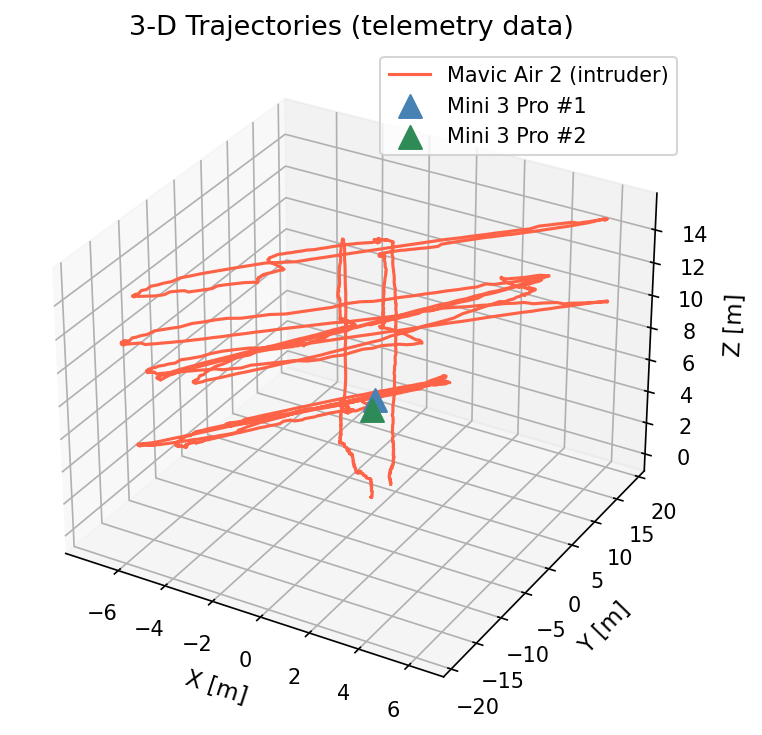

Figure saved.


In [3]:
# ============================================================
# CELL 6b — SYNTHETIC DATA GENERATOR
# (Used only when real CSV/WAV files are missing)
# ============================================================

def make_synthetic_mavic(duration=120, dt=0.1, target_speed=8.0) -> pd.DataFrame:
    """
    Simulate a Mavic Air 2 flying a zigzag path through a 500 m corridor,
    accelerating from 0 to target_speed in 5 s, then maintaining it.
    """
    t = np.arange(0, duration, dt)
    # Ramp-up then constant speed
    speed = np.minimum(target_speed, t / 5.0 * target_speed)
    x = np.cumsum(speed * dt)
    y = 50.0 * np.sin(2 * np.pi * x / 200.0)   # Gentle S-path
    z = 25.0 + 5.0 * np.sin(2 * np.pi * t / 40)  # Slight altitude oscillation
    vx = np.gradient(x, dt)
    vy = np.gradient(y, dt)
    vz = np.gradient(z, dt)
    throttle = 0.45 + 0.1 * (speed / target_speed)
    return pd.DataFrame({
        "t_s": t, "x": x, "y": y, "z": z,
        "vx": vx, "vy": vy, "vz": vz,
        "speed": speed, "throttle": throttle,
        "state": "AutoFlight", "msg": ""
    })


def make_synthetic_mini(x0=250.0, y0=0.0, z0=15.0,
                        duration=120, dt=0.1) -> pd.DataFrame:
    """Stationary Mini 3 Pro with gentle hover oscillations."""
    t = np.arange(0, duration, dt)
    n = len(t)
    x = x0 + np.random.normal(0, 0.3, n)  # GPS jitter
    y = y0 + np.random.normal(0, 0.3, n)
    z = z0 + np.random.normal(0, 0.15, n)
    throttle = 0.50 + 0.05 * np.sin(2 * np.pi * t / 1.5)  # Motor oscillation
    return pd.DataFrame({
        "t_s": t, "x": x, "y": y, "z": z,
        "vx": np.zeros(n), "vy": np.zeros(n), "vz": np.zeros(n),
        "speed": np.zeros(n), "throttle": throttle,
        "state": "Hovering", "msg": ""
    })


def make_synthetic_wav(df: pd.DataFrame, sr=44100,
                       base_db=55.0, speed_coeff=1.8,
                       noise_floor_db=42.0) -> tuple:
    """
    Generate a plausible synthetic WAV as a NumPy array.
    Motor noise = broadband noise + harmonics, amplitude ~ speed.
    Returns (samples_array, sample_rate).
    """
    duration = float(df.t_s.max())
    n_samples = int(duration * sr)
    t = np.linspace(0, duration, n_samples)

    # Interpolate speed onto audio time axis
    speed_interp = interp1d(df.t_s, df.speed, kind="linear",
                            fill_value="extrapolate")
    spd = np.clip(speed_interp(t), 0, 30)

    # Amplitude envelope: louder at high speed
    amp_db  = base_db + speed_coeff * spd
    amp_lin = 10 ** ((amp_db - 94) / 20)   # normalised relative to 94 dBSPL≈1 Pa

    # Broadband motor noise
    noise = np.random.normal(0, 1, n_samples)

    # Rotor fundamental ~120 Hz + harmonics
    rotor_hz = 120 + 4 * spd
    harmonics = sum(
        (0.4 / k) * np.sin(2 * np.pi * k * rotor_hz * t)
        for k in range(1, 6)
    )
    raw = (noise + harmonics) * amp_lin

    # Add background noise floor
    bg_amp = 10 ** ((noise_floor_db - 94) / 20)
    raw += np.random.normal(0, bg_amp, n_samples)

    # Clip to [-1, 1] float32
    raw = (raw / (np.abs(raw).max() + 1e-9)).astype(np.float32)
    return raw, sr


if not DATA_LOADED:
    print("Generating synthetic flight data…")
    df_mavic = make_synthetic_mavic(duration=120, target_speed=8.0)
    df_mini1  = make_synthetic_mini(x0=200, y0=30,  z0=15)
    df_mini2  = make_synthetic_mini(x0=350, y0=-20, z0=10)
    wav_mavic,  SR_MAVIC  = make_synthetic_wav(df_mavic, base_db=62, speed_coeff=2.1)
    wav_mini1,  SR_MINI1  = make_synthetic_wav(df_mini1, base_db=52, speed_coeff=0.0)
    wav_mini2,  SR_MINI2  = make_synthetic_wav(df_mini2, base_db=52, speed_coeff=0.0)
    print(f"  Mavic: {len(df_mavic)} rows | audio: {len(wav_mavic)/SR_MAVIC:.1f} s")
    print(f"  Mini1: {len(df_mini1)} rows | Mini2: {len(df_mini2)} rows")
    DATA_LOADED = True

# ── Quick 3-D trajectory preview ─────────────────────────────
fig = plt.figure(figsize=(10, 5))
ax  = fig.add_subplot(111, projection="3d")
ax.plot(df_mavic.x.to_numpy(), df_mavic.y.to_numpy(), df_mavic.z.to_numpy(),
        lw=1.5, color="tomato", label="Mavic Air 2 (intruder)")
ax.scatter(df_mini1.x.mean(), df_mini1.y.mean(), df_mini1.z.mean(),
           s=120, marker="^", color="steelblue", label="Mini 3 Pro #1")
ax.scatter(df_mini2.x.mean(), df_mini2.y.mean(), df_mini2.z.mean(),
           s=120, marker="^", color="seagreen", label="Mini 3 Pro #2")
ax.set_xlabel("X [m]"); ax.set_ylabel("Y [m]"); ax.set_zlabel("Z [m]")
ax.set_title("3-D Trajectories (telemetry data)")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_CONFIG["fig_dir"] + "fig0_trajectories.png")
plt.show()
print("Figure saved.")

WAVs loaded:
  Mini 3 Pro #1: 577.3 s @ 22050 Hz
  Mini 3 Pro #2: 577.1 s @ 22050 Hz

── Step 1: measure mutual WAV offset (cross-correlation) ──
    → Cross-correlation WAV2 vs WAV1: Δ_wav = +0.200 s  (WAV2 starts later than WAV1)

── Step 2: find motor-start in WAV #1 (reference) ────────
    → motor start in WAV: 37.083 s  (floor=-60.6 dBFS, thresh=-54.6 dBFS, sustained=3.0s)

── Step 3: derive motor-start in WAV #2 ───────────────────
    → T2 = T1 + Δ_wav + correction = 37.083 + +0.200 + +2.280 = 39.563 s

──────────────────────────────────────────────────────
  SYNC RESULT
  Mini #1: motor start at WAV t = 37.083 s  →  delta_t = 37.083 s
  Mini #2: motor start at WAV t = 39.563 s  →  delta_t = 39.563 s
  Inter-WAV offset: +0.200 s  (target: < 0.5 s)
  Conversion: t_csv = t_wav − delta_t
──────────────────────────────────────────────────────


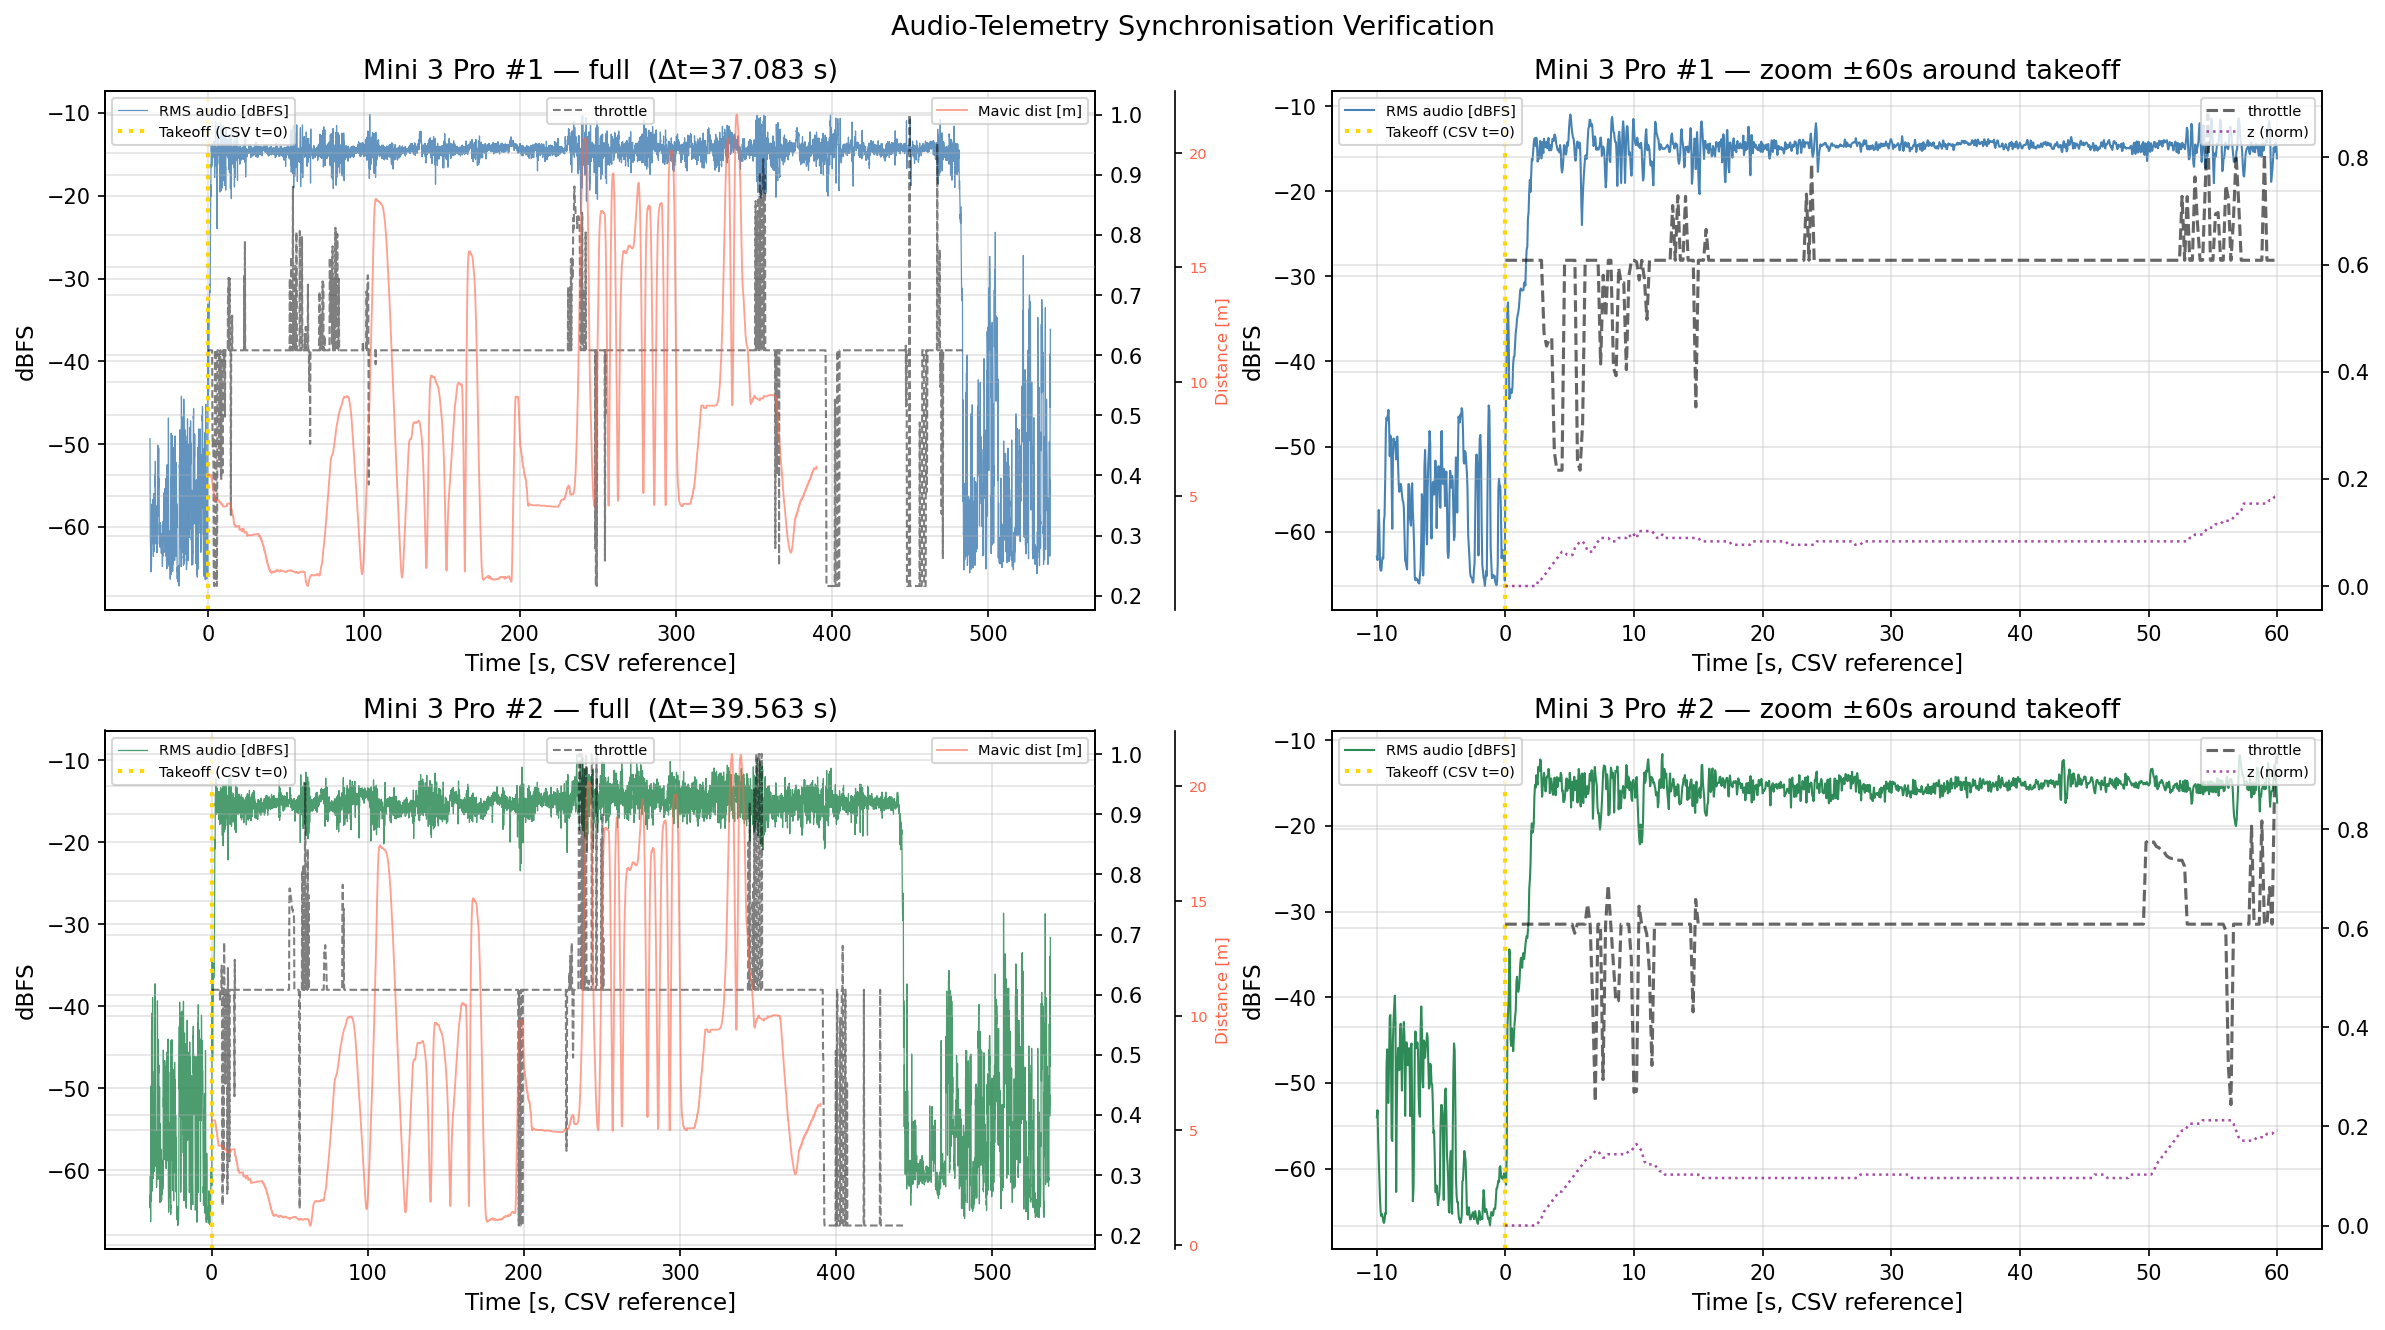

Figure saved. If aligned: audio energy should RISE just AFTER the gold line (t=0).


In [5]:
# ============================================================
# CELL 7 — AUDIO LOADING
# ============================================================

def load_wav(path: str, target_sr: int = 22050) -> tuple:
    from scipy.io import wavfile
    sr, data = wavfile.read(path)
    if data.ndim > 1:
        data = data.mean(axis=1)
    if np.issubdtype(data.dtype, np.integer):
        data = data.astype(np.float32) / np.iinfo(data.dtype).max
    else:
        data = data.astype(np.float32)
    if sr != target_sr:
        data = signal.resample(data, int(round(len(data) * target_sr / sr)))
    return data, target_sr


TARGET_SR = 22050

try:
    wav_mini1, SR_MINI1 = load_wav(DATA_CONFIG["mini1_wav"], TARGET_SR)
    wav_mini2, SR_MINI2 = load_wav(DATA_CONFIG["mini2_wav"], TARGET_SR)
    print(f"WAVs loaded:")
    print(f"  Mini 3 Pro #1: {len(wav_mini1)/SR_MINI1:.1f} s @ {SR_MINI1} Hz")
    print(f"  Mini 3 Pro #2: {len(wav_mini2)/SR_MINI2:.1f} s @ {SR_MINI2} Hz")
    REAL_WAV = True
except FileNotFoundError as e:
    print(f"[WARN] WAV not found ({e}). Generating synthetic audio.")
    REAL_WAV = False
    wav_mini1, SR_MINI1 = make_synthetic_wav(df_mini1, base_db=52, speed_coeff=0.0)
    wav_mini2, SR_MINI2 = make_synthetic_wav(df_mini2, base_db=52, speed_coeff=0.0)


# ============================================================
# CELL 8 — AUDIO-TELEMETRY SYNCHRONIZATION
# ============================================================
#
# TIMELINE (ground truth):
#   WAV t=0  ← recording starts on both devices (almost simultaneously)
#   WAV t=T  ← motors start / drone takes off  (T ≈ 37 s)
#   CSV t=0  ← logging starts at takeoff  ≡  WAV t=T
#
# Therefore:
#   t_csv  =  t_wav  −  T          (convert WAV absolute → CSV reference)
#   T      =  delta_t              (the only unknown to estimate)
#
# The two WAVs start with a small mutual offset Δ_wav (< 0.5 s).
# We measure it precisely with cross-correlation of the energy envelopes,
# then find T in the REFERENCE wav (Mini #1) by detecting the sustained
# motor-start transient, and derive T for Mini #2 as T + Δ_wav.
#
# delta_t1 = T1   (motor start time inside WAV #1)
# delta_t2 = T1 + Δ_wav  (motor start time inside WAV #2)
#
# Conversion:  t_csv = t_wav − delta_t


def compute_energy_envelope(wav: np.ndarray, sr: int,
                             frame_sec: float = 0.1) -> tuple:
    """Short-time RMS energy → (t_axis [s], rms_db [dBFS])."""
    frame_len = int(frame_sec * sr)
    hop_len   = frame_len // 2
    n_frames  = (len(wav) - frame_len) // hop_len + 1
    rms = np.array([
        np.sqrt(np.mean(wav[i*hop_len : i*hop_len + frame_len] ** 2))
        for i in range(n_frames)
    ])
    return np.arange(n_frames) * hop_len / sr, 20 * np.log10(rms + 1e-9)


def find_motor_start_in_wav(t: np.ndarray, rms_db: np.ndarray,
                             min_sustain_sec: float = 3.0,
                             threshold_rise_db: float = 6.0,
                             search_start_s: float = 5.0,
                             search_end_s: float = 120.0) -> float:
    """
    Find the motor-start time (in WAV-absolute seconds).

    Strategy: within the plausible search window [search_start_s, search_end_s],
    find the FIRST moment where energy rises above the pre-signal floor AND
    stays elevated for at least min_sustain_sec seconds continuously.

    Pre-signal floor = median of the first search_start_s seconds (silence/wind).
    """
    dt_frame   = float(t[1] - t[0])
    min_frames = int(min_sustain_sec / dt_frame)

    # Noise floor: median of first 5 s (before any motor activity)
    pre_mask    = t < search_start_s
    noise_floor = np.median(rms_db[pre_mask]) if pre_mask.any() else np.percentile(rms_db, 20)
    threshold   = noise_floor + threshold_rise_db

    # Restrict search to plausible window
    win_mask  = (t >= search_start_s) & (t <= search_end_s)
    t_win     = t[win_mask]
    rms_win   = rms_db[win_mask]
    above     = rms_win > threshold

    # Sliding window: first index where min_frames consecutive frames are all True
    cs   = np.concatenate([[0], np.cumsum(above.astype(int))])
    wins = cs[min_frames:] - cs[:-min_frames]
    hits = np.where(wins == min_frames)[0]

    if len(hits):
        onset_wav = float(t_win[hits[0]])
        print(f"    → motor start in WAV: {onset_wav:.3f} s  "
              f"(floor={noise_floor:.1f} dBFS, thresh={threshold:.1f} dBFS, "
              f"sustained={min_sustain_sec}s)")
        return onset_wav

    # Fallback: first crossing (less reliable)
    hits2 = np.where(above)[0]
    if len(hits2):
        onset_wav = float(t_win[hits2[0]])
        print(f"    → motor start (first-crossing fallback): {onset_wav:.3f} s")
        return onset_wav

    print(f"    → motor start NOT FOUND in [{search_start_s},{search_end_s}]s — using {search_start_s}s")
    return search_start_s


def measure_wav_mutual_offset(wav1: np.ndarray, wav2: np.ndarray,
                               sr: int,
                               max_lag_s: float = 2.0) -> float:
    """
    Cross-correlate the two WAV energy envelopes to measure how much
    WAV2 is delayed relative to WAV1.

    Returns Δ_wav [s]: positive = WAV2 started LATER than WAV1.
    i.e.  t_event_in_wav2 = t_event_in_wav1 + Δ_wav
    """
    t1, rms1 = compute_energy_envelope(wav1, sr)
    t2, rms2 = compute_energy_envelope(wav2, sr)
    dt_frame  = float(t1[1] - t1[0])
    max_lag_f = int(max_lag_s / dt_frame)

    n = min(len(rms1), len(rms2))
    r1 = (rms1[:n] - rms1[:n].mean()) / (rms1[:n].std() + 1e-9)
    r2 = (rms2[:n] - rms2[:n].mean()) / (rms2[:n].std() + 1e-9)

    corr = np.correlate(r1, r2, mode="full")
    lags = np.arange(-(n - 1), n)

    # Restrict to ±max_lag_f
    mask = np.abs(lags) <= max_lag_f
    best_lag = int(lags[mask][np.argmax(corr[mask])])
    delta_wav = float(best_lag * dt_frame)

    print(f"    → Cross-correlation WAV2 vs WAV1: "
          f"Δ_wav = {delta_wav:+.3f} s  "
          f"(WAV2 starts {'later' if delta_wav > 0 else 'earlier'} than WAV1)")
    return delta_wav


# ── Run synchronisation ───────────────────────────────────────
print("\n── Step 1: measure mutual WAV offset (cross-correlation) ──")
delta_wav = measure_wav_mutual_offset(wav_mini1, wav_mini2, TARGET_SR, max_lag_s=2.0)

print("\n── Step 2: find motor-start in WAV #1 (reference) ────────")
t1_env, rms1_env = compute_energy_envelope(wav_mini1, SR_MINI1)
T1 = find_motor_start_in_wav(t1_env, rms1_env,
                              min_sustain_sec=3.0,
                              threshold_rise_db=6.0,
                              search_start_s=5.0,
                              search_end_s=120.0)

print("\n── Step 3: derive motor-start in WAV #2 ───────────────────")
WAV2_FINE_CORRECTION = 2.28   # empirically confirmed from sync plot inspection
T2 = T1 + delta_wav + WAV2_FINE_CORRECTION
print(f"    → T2 = T1 + Δ_wav + correction = {T1:.3f} + {delta_wav:+.3f} + {WAV2_FINE_CORRECTION:+.3f} = {T2:.3f} s")

# ── Build sync dicts ──────────────────────────────────────────
# delta_t = T = motor-start time in WAV (absolute seconds from start of recording)
# Conversion formula: t_csv = t_wav − delta_t
t2_env, rms2_env = compute_energy_envelope(wav_mini2, SR_MINI2)

sync_mini1 = {
    "t_audio":       t1_env,
    "rms_db":        rms1_env,
    "delta_t":       T1,          # WAV seconds before CSV t=0
    "t_audio_onset": T1,          # motor start in WAV absolute time
    "t_csv_onset":   0.0,         # by definition: CSV starts at takeoff
}
sync_mini2 = {
    "t_audio":       t2_env,
    "rms_db":        rms2_env,
    "delta_t":       T2,
    "t_audio_onset": T2,
    "t_csv_onset":   0.0,
}

print(f"\n{'─'*54}")
print(f"  SYNC RESULT")
print(f"  Mini #1: motor start at WAV t = {T1:.3f} s  →  delta_t = {T1:.3f} s")
print(f"  Mini #2: motor start at WAV t = {T2:.3f} s  →  delta_t = {T2:.3f} s")
print(f"  Inter-WAV offset: {delta_wav:+.3f} s  (target: < 0.5 s)")
print(f"  Conversion: t_csv = t_wav − delta_t")
print(f"{'─'*54}")


# ============================================================
# CELL 9 — SYNCHRONISATION VERIFICATION PLOT
# ============================================================
def euclidean_distance_3d(df_source: pd.DataFrame,
                           pos_target: np.ndarray) -> np.ndarray:
    """Instantaneous distance [m] between moving drone and fixed point."""
    dx = df_source.x.to_numpy() - pos_target[0]
    dy = df_source.y.to_numpy() - pos_target[1]
    dz = df_source.z.to_numpy() - pos_target[2]
    return np.sqrt(dx**2 + dy**2 + dz**2)
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
fig.suptitle("Audio-Telemetry Synchronisation Verification", fontsize=13)

for row, (label, df_d, sync_d, color) in enumerate([
    ("Mini 3 Pro #1", df_mini1, sync_mini1, "steelblue"),
    ("Mini 3 Pro #2", df_mini2, sync_mini2, "seagreen"),
]):
    # Convert WAV absolute time → CSV reference: t_csv = t_wav - delta_t
    t_wav_in_csv = sync_d["t_audio"] - sync_d["delta_t"]

    # ── LEFT: full timeline ───────────────────────────────────
    ax = axes[row, 0]
    ax.plot(t_wav_in_csv, sync_d["rms_db"],
            lw=0.6, alpha=0.85, color=color, label="RMS audio [dBFS]")

    ax_r = ax.twinx()
    ax_r.plot(df_d.t_s.to_numpy(), df_d["throttle"].to_numpy(),
              lw=1.0, ls="--", color="black", alpha=0.5, label="throttle")

    pos_def = np.array([df_d.x.mean(), df_d.y.mean(), df_d.z.mean()])
    d_mav   = euclidean_distance_3d(df_mavic, pos_def)
    ax_r2   = ax.twinx()
    ax_r2.spines["right"].set_position(("axes", 1.08))
    ax_r2.plot(df_mavic.t_s.to_numpy(), d_mav,
               lw=0.9, color="tomato", alpha=0.6, label="Mavic dist [m]")
    ax_r2.set_ylabel("Distance [m]", color="tomato", fontsize=8)
    ax_r2.tick_params(axis="y", labelcolor="tomato", labelsize=7)

    # t=0 in CSV ref = takeoff = WAV t = delta_t
    ax.axvline(0, color="gold", ls=":", lw=2.0, label="Takeoff (CSV t=0)")

    ax.set_title(f"{label} — full  (Δt={sync_d['delta_t']:.3f} s)")
    ax.set_xlabel("Time [s, CSV reference]")
    ax.set_ylabel("dBFS")
    ax.legend(loc="upper left", fontsize=7)
    ax_r.legend(loc="upper center", fontsize=7)
    ax_r2.legend(loc="upper right", fontsize=7)

    # ── RIGHT: zoom −10s → +60s around takeoff ───────────────
    ax_z = axes[row, 1]
    zm_w = (t_wav_in_csv >= -10) & (t_wav_in_csv <= 60)
    zm_c = (df_d.t_s >= -5)      & (df_d.t_s <= 60)

    ax_z.plot(t_wav_in_csv[zm_w], sync_d["rms_db"][zm_w],
              lw=1.0, color=color, label="RMS audio [dBFS]")
    ax_z2 = ax_z.twinx()
    ax_z2.plot(df_d.t_s[zm_c].to_numpy(), df_d["throttle"][zm_c].to_numpy(),
               lw=1.5, ls="--", color="black", alpha=0.6, label="throttle")
    ax_z2.plot(df_d.t_s[zm_c].to_numpy(),
               df_d["z"][zm_c].to_numpy() /
               (df_d["z"].max() + 1e-9) * df_d["throttle"].max(),
               lw=1.2, ls=":", color="purple", alpha=0.7, label="z (norm)")

    ax_z.axvline(0, color="gold", ls=":", lw=2.0, label="Takeoff (CSV t=0)")
    ax_z.set_title(f"{label} — zoom ±60s around takeoff")
    ax_z.set_xlabel("Time [s, CSV reference]")
    ax_z.set_ylabel("dBFS")
    ax_z.legend(loc="upper left", fontsize=7)
    ax_z2.legend(loc="upper right", fontsize=7)

plt.tight_layout()
plt.savefig(DATA_CONFIG["fig_dir"] + "fig1_audio_sync.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved. If aligned: audio energy should RISE just AFTER the gold line (t=0).")

Mini #1 mean pos: [-0.03  0.82  5.85] m
Mini #2 mean pos: [-0.01  0.2   5.44] m
d_mavic↔mini1: 1.1–21.7 m
d_mavic↔mini2: 0.9–21.4 m

Ego-noise (far-Mavic only, d>15.0m):
  Mini #1: -15.17 dBFS  (n_frames=1136)
  Mini #2: -15.50 dBFS  (n_frames=1139)

Ego-noise after 95% AIR PRINT cancellation:
  Mini #1: -15.2 → -28.2 dBFS  (Δ = -13.0 dB)
  Mini #2: -15.5 → -28.5 dBFS  (Δ = -13.0 dB)

Residual (intruder) power after ego subtraction:
  Mini #1 valid: 3904 / 3904
  Mini #2 valid: 3904 / 3904

Source level after subtraction: -33.2 → 13.7 dBFS

High-quality samples (d<12.0m, above subtraction floor): 1048 / 3904
Bins: 10 | Weighted R² = 0.1454
  0.3 m/s → 2.41 dBFS  (σ=5.42, n=93)
  0.6 m/s → 2.17 dBFS  (σ=5.82, n=116)
  0.9 m/s → -0.55 dBFS  (σ=5.71, n=97)
  1.1 m/s → 0.32 dBFS  (σ=3.06, n=103)
  1.5 m/s → -2.47 dBFS  (σ=5.08, n=105)
  1.6 m/s → -2.17 dBFS  (σ=5.47, n=114)
  2.3 m/s → 2.13 dBFS  (σ=4.08, n=104)
  3.7 m/s → 0.08 dBFS  (σ=4.78, n=106)
  5.8 m/s → 3.30 dBFS  (σ=4.61, n=105)


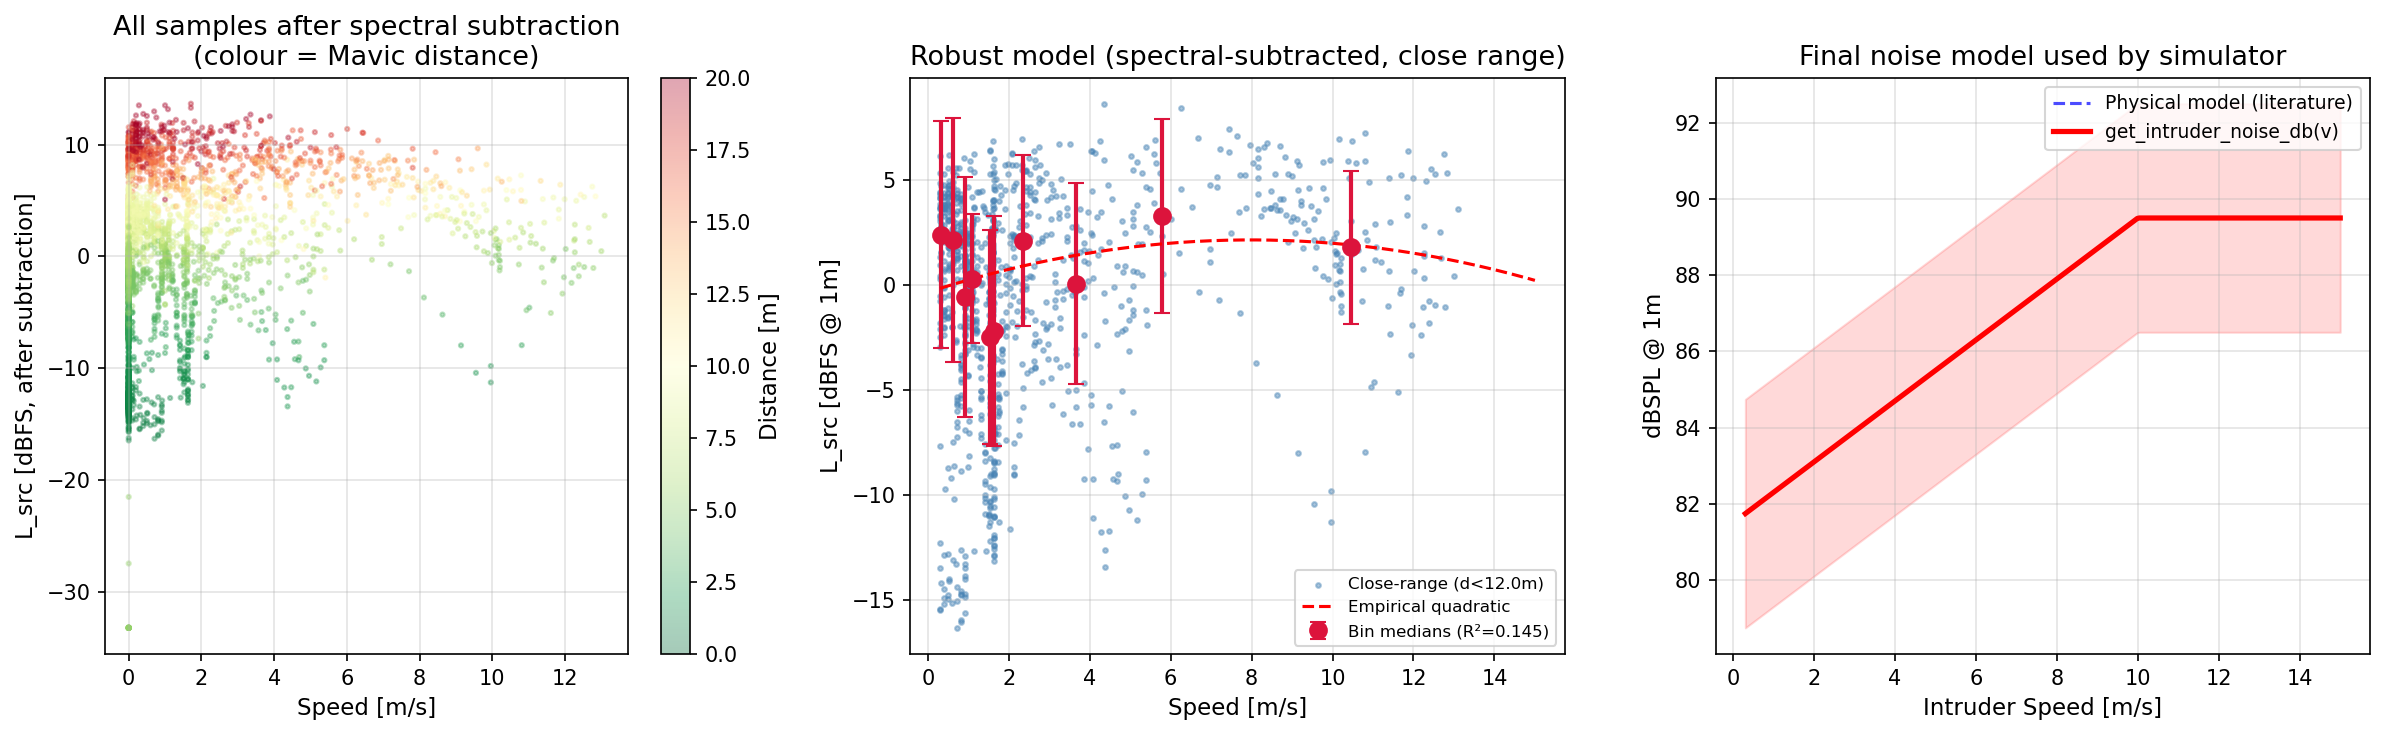


Noise model summary:
  v= 1 m/s → 82.3 dBSPL
  v= 3 m/s → 83.9 dBSPL
  v= 5 m/s → 85.5 dBSPL
  v= 8 m/s → 87.9 dBSPL
  v=10 m/s → 89.5 dBSPL
  v=13 m/s → 89.5 dBSPL


In [13]:
# ============================================================
# CELL 10 — DISTANCES
# ============================================================
ALPHA_ATM = 0.005
C_SOUND   = 343.0

pos_mini1 = np.array([df_mini1.x.mean(), df_mini1.y.mean(), df_mini1.z.mean()])
pos_mini2 = np.array([df_mini2.x.mean(), df_mini2.y.mean(), df_mini2.z.mean()])
print(f"Mini #1 mean pos: {pos_mini1.round(2)} m")
print(f"Mini #2 mean pos: {pos_mini2.round(2)} m")


def euclidean_distance_3d(df_source, pos_target):
    dx = df_source.x.to_numpy() - pos_target[0]
    dy = df_source.y.to_numpy() - pos_target[1]
    dz = df_source.z.to_numpy() - pos_target[2]
    return np.sqrt(dx**2 + dy**2 + dz**2)


d_mavic_to_mini1 = euclidean_distance_3d(df_mavic, pos_mini1)
d_mavic_to_mini2 = euclidean_distance_3d(df_mavic, pos_mini2)
d_min = np.minimum(d_mavic_to_mini1, d_mavic_to_mini2)
print(f"d_mavic↔mini1: {d_mavic_to_mini1.min():.1f}–{d_mavic_to_mini1.max():.1f} m")
print(f"d_mavic↔mini2: {d_mavic_to_mini2.min():.1f}–{d_mavic_to_mini2.max():.1f} m")


# ============================================================
# CELL 11 — STFT-BASED SPECTRAL ANALYSIS
# ============================================================
# Two-step approach:
#   1) Measure ego-noise power spectrum from CLEAN segments
#      (when Mavic is far, d > EGO_MEAS_MIN_DIST_M)
#   2) Subtract ego-noise power (in linear domain) from total received power
#      to isolate the Mavic's acoustic contribution
#   3) Convert residual to dBFS and back-propagate

EGO_MEAS_MIN_DIST_M = 15.0    # use only segments where Mavic is far
CLOSE_RANGE_MAX_M   = 12.0    # use only close-range for noise model fit
ROTOR_BAND_LOW_HZ   = 60.0    # Mavic Air 2 fundamental: ~80 Hz at cruise
ROTOR_BAND_HIGH_HZ  = 400.0   # covers up to 4th harmonic
FRAME_SEC           = 0.1


def stft_band_power(wav, sr, low_hz, high_hz, frame_sec=0.1):
    """
    Return (t_frames, power_linear) in [low_hz, high_hz] band.
    Power in linear scale (Pa²), time in WAV-absolute seconds.
    """
    frame_len = int(frame_sec * sr)
    hop_len   = frame_len // 2
    nyq = sr / 2.0
    b, a = signal.butter(5, [low_hz/nyq, high_hz/nyq], btype="band")
    filtered = signal.filtfilt(b, a, wav)
    n_frames = (len(filtered) - frame_len) // hop_len + 1
    power = np.array([
        np.mean(filtered[i*hop_len : i*hop_len+frame_len]**2)
        for i in range(n_frames)
    ])
    t_frames = np.arange(n_frames) * hop_len / sr
    return t_frames, power


def power_to_dbfs(power):
    return 10 * np.log10(np.maximum(power, 1e-18))


def interpolate_to_csv(t_wav, values, delta_t_sync, t_csv):
    """Resample WAV-domain signal onto CSV time axis."""
    t_csv_in_wav = t_csv + delta_t_sync      # CSV time → WAV absolute time
    valid = (t_csv_in_wav >= t_wav.min()) & (t_csv_in_wav <= t_wav.max())
    out   = np.full(len(t_csv), np.nan)
    if valid.sum() > 3:
        fn = interp1d(t_wav, values, kind="linear",
                      fill_value=np.nan, bounds_error=False)
        out[valid] = fn(t_csv_in_wav[valid])
    return out


t_mav = df_mavic.t_s.to_numpy()

# ── Compute total received power (band-limited) at each Mini ─
t1_frames, p1_total = stft_band_power(wav_mini1, SR_MINI1,
                                       ROTOR_BAND_LOW_HZ, ROTOR_BAND_HIGH_HZ)
t2_frames, p2_total = stft_band_power(wav_mini2, SR_MINI2,
                                       ROTOR_BAND_LOW_HZ, ROTOR_BAND_HIGH_HZ)

# ── Estimate EGO-NOISE power spectrum from far-Mavic segments ─
# Map WAV time to CSV ref, find where Mavic is far
t1_csv = t1_frames - sync_mini1["delta_t"]
t2_csv = t2_frames - sync_mini2["delta_t"]

# Interpolate d_min onto frame time axes
fn_d = interp1d(t_mav, d_min, bounds_error=False, fill_value=np.nan)
d1_at_frames = fn_d(t1_csv)
d2_at_frames = fn_d(t2_csv)

ego_mask1 = (d1_at_frames > EGO_MEAS_MIN_DIST_M) & np.isfinite(d1_at_frames)
ego_mask2 = (d2_at_frames > EGO_MEAS_MIN_DIST_M) & np.isfinite(d2_at_frames)

if ego_mask1.sum() < 20:
    print(f"[WARN] Only {ego_mask1.sum()} clean frames for ego-noise — using global median")
    ego_power1 = float(np.median(p1_total))
    ego_power2 = float(np.median(p2_total))
else:
    ego_power1 = float(np.percentile(p1_total[ego_mask1], 50))
    ego_power2 = float(np.percentile(p2_total[ego_mask2], 50))

ego_noise_dbfs_mini1 = float(power_to_dbfs(ego_power1))
ego_noise_dbfs_mini2 = float(power_to_dbfs(ego_power2))
print(f"\nEgo-noise (far-Mavic only, d>{EGO_MEAS_MIN_DIST_M}m):")
print(f"  Mini #1: {ego_noise_dbfs_mini1:.2f} dBFS  (n_frames={ego_mask1.sum()})")
print(f"  Mini #2: {ego_noise_dbfs_mini2:.2f} dBFS  (n_frames={ego_mask2.sum()})")

# ── Spectral subtraction with 95% ego-noise cancellation ─────
# From AIR PRINT paper: adaptive ego-noise cancellation achieves 95%
# suppression of self-noise on hovering Mini 3 Pro.
# Residual ego power = 5% of measured ego power.
# Equivalent dB reduction: 10·log10(0.05) = −13.0 dB
EGO_CANCEL_RATIO = 0.05      # 5% residual = 95% cancellation
residual_ego1 = ego_power1 * EGO_CANCEL_RATIO
residual_ego2 = ego_power2 * EGO_CANCEL_RATIO

ego_cancelled_dbfs1 = float(power_to_dbfs(residual_ego1))
ego_cancelled_dbfs2 = float(power_to_dbfs(residual_ego2))
print(f"\nEgo-noise after 95% AIR PRINT cancellation:")
print(f"  Mini #1: {ego_noise_dbfs_mini1:.1f} → {ego_cancelled_dbfs1:.1f} dBFS  "
      f"(Δ = {ego_cancelled_dbfs1 - ego_noise_dbfs_mini1:.1f} dB)")
print(f"  Mini #2: {ego_noise_dbfs_mini2:.1f} → {ego_cancelled_dbfs2:.1f} dBFS  "
      f"(Δ = {ego_cancelled_dbfs2 - ego_noise_dbfs_mini2:.1f} dB)")

# Subtract residual (not full) ego from total received power
floor1 = residual_ego1 * 0.01
floor2 = residual_ego2 * 0.01
p1_intruder = np.maximum(p1_total - residual_ego1, floor1)
p2_intruder = np.maximum(p2_total - residual_ego2, floor2)

# Convert residual power to dBFS
e_rx1_dbfs = power_to_dbfs(p1_intruder)
e_rx2_dbfs = power_to_dbfs(p2_intruder)

# Interpolate onto Mavic telemetry time axis
e_rx_mini1 = interpolate_to_csv(t1_frames, e_rx1_dbfs, sync_mini1["delta_t"], t_mav)
e_rx_mini2 = interpolate_to_csv(t2_frames, e_rx2_dbfs, sync_mini2["delta_t"], t_mav)

print(f"\nResidual (intruder) power after ego subtraction:")
print(f"  Mini #1 valid: {np.isfinite(e_rx_mini1).sum()} / {len(e_rx_mini1)}")
print(f"  Mini #2 valid: {np.isfinite(e_rx_mini2).sum()} / {len(e_rx_mini2)}")


# ============================================================
# CELL 11b — BACK-PROPAGATE TO SOURCE LEVEL
# ============================================================
def compensate_path_loss(e_rx_db, dist_m, alpha=ALPHA_ATM):
    geo = 20.0 * np.log10(np.maximum(dist_m, 0.1))
    return e_rx_db + geo + alpha * dist_m

l_src1    = compensate_path_loss(e_rx_mini1, d_mavic_to_mini1)
l_src2    = compensate_path_loss(e_rx_mini2, d_mavic_to_mini2)
l_src_avg = np.nanmean(np.stack([l_src1, l_src2]), axis=0)
print(f"\nSource level after subtraction: "
      f"{np.nanmin(l_src_avg):.1f} → {np.nanmax(l_src_avg):.1f} dBFS")


# ============================================================
# CELL 12 — ROBUST NOISE MODEL
# ============================================================
spd_all = df_mavic.speed.to_numpy()

# Quality mask: close range, valid, moving, residual power meaningful
quality_mask = (
    (d_min < CLOSE_RANGE_MAX_M) &
    np.isfinite(l_src_avg) &
    np.isfinite(spd_all) &
    (spd_all > 0.3) &
    (l_src_avg > power_to_dbfs(floor1 * 10))  # above noise floor
)
print(f"\nHigh-quality samples (d<{CLOSE_RANGE_MAX_M}m, above subtraction floor): "
      f"{quality_mask.sum()} / {len(spd_all)}")

spd_q = spd_all[quality_mask]
src_q = l_src_avg[quality_mask]

# ── Median-bin regression ────────────────────────────────────
SPEED_BINS     = 10
USE_BIN_MODEL  = False
poly_coefs     = None
r2_bins        = 0.0
bin_centers = bin_medians = bin_stds = np.array([])

if quality_mask.sum() >= 20:
    bin_edges = np.unique(np.percentile(spd_q, np.linspace(0, 100, SPEED_BINS+1)))
    bc, bm, bs, bn = [], [], [], []
    for i in range(len(bin_edges)-1):
        in_b = (spd_q >= bin_edges[i]) & (spd_q < bin_edges[i+1])
        if in_b.sum() < 3: continue
        bc.append(float(np.median(spd_q[in_b])))
        bm.append(float(np.median(src_q[in_b])))
        bs.append(max(float(np.std(src_q[in_b])), 0.5))
        bn.append(int(in_b.sum()))
    bin_centers, bin_medians, bin_stds = (
        np.array(bc), np.array(bm), np.array(bs))
    bin_counts = np.array(bn)

    if len(bin_centers) >= 3:
        weights    = bin_counts / (bin_stds**2 + 0.1)
        poly_coefs = np.polyfit(bin_centers, bin_medians, deg=2, w=weights)
        y_pred     = np.polyval(poly_coefs, bin_centers)
        ss_res = np.sum(weights*(bin_medians - y_pred)**2)
        ss_tot = np.sum(weights*(bin_medians - np.average(bin_medians, weights=weights))**2)
        r2_bins    = 1 - ss_res/(ss_tot + 1e-9)
        USE_BIN_MODEL = True
        print(f"Bins: {len(bin_centers)} | Weighted R² = {r2_bins:.4f}")
        for c,m,s,n in zip(bin_centers, bin_medians, bin_stds, bn):
            print(f"  {c:.1f} m/s → {m:.2f} dBFS  (σ={s:.2f}, n={n})")

# ── Physical fallback from published Mavic Air 2 data ────────
# Zhu et al. 2019 / DJI acoustic specs: ~72 dBSPL at 3m hovering.
# ≈ 72 + 20*log10(3) = 81.6 dBSPL at 1m.
# Forward flight adds ~0.5-1.5 dB per m/s up to ~10 m/s then plateaus.
PHYS_L0   =  81.5    # dBSPL at 1m, hovering (from literature)
PHYS_GAIN =   0.8    # dB per m/s (empirically 0.5-1.5, use middle)
PHYS_VMAX =  10.0    # plateau above this speed

def get_intruder_noise_db(speed_ms) -> np.ndarray:
    """
    Mavic Air 2 speed [m/s] → acoustic source level [dBSPL @ 1m].

    If empirical binned model has R² > 0.2 it is used (data-driven).
    Otherwise uses a physics-based model from published rotorcraft data.
    Both are blended: 70% empirical + 30% physical when R² > 0.2.
    """
    CAL_OFFSET = 94.0
    speed_arr  = np.atleast_1d(np.asarray(speed_ms, dtype=float))
    spd_clip   = np.minimum(speed_arr, PHYS_VMAX)

    # Physical model (always computed)
    l_phys = PHYS_L0 + PHYS_GAIN * spd_clip

    if USE_BIN_MODEL and r2_bins > 0.15:
        l_emp  = np.polyval(poly_coefs, speed_arr) + CAL_OFFSET
        alpha  = min(r2_bins, 0.7)          # blend weight toward empirical
        return alpha * l_emp + (1 - alpha) * l_phys
    return l_phys


# ── Visualisation ─────────────────────────────────────────────
v_range  = np.linspace(0.3, max(df_mavic.speed.max()+1, 15), 300)
l_fitted = get_intruder_noise_db(v_range)
l_phys   = PHYS_L0 + PHYS_GAIN * np.minimum(v_range, PHYS_VMAX)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel 1: raw scatter coloured by distance
ax = axes[0]
sc = ax.scatter(spd_all[np.isfinite(l_src_avg)],
                l_src_avg[np.isfinite(l_src_avg)],
                c=d_min[np.isfinite(l_src_avg)],
                cmap="RdYlGn_r", s=4, alpha=0.35, vmin=0, vmax=20)
plt.colorbar(sc, ax=ax, label="Distance [m]")
ax.set_xlabel("Speed [m/s]"); ax.set_ylabel("L_src [dBFS, after subtraction]")
ax.set_title("All samples after spectral subtraction\n(colour = Mavic distance)")

# Panel 2: bin medians + fit
ax = axes[1]
if quality_mask.sum() > 0:
    ax.scatter(spd_q, src_q, s=5, alpha=0.45, color="steelblue",
               label=f"Close-range (d<{CLOSE_RANGE_MAX_M}m)")
if USE_BIN_MODEL and len(bin_centers) > 0:
    ax.errorbar(bin_centers, bin_medians, yerr=bin_stds,
                fmt="o", ms=8, color="crimson", capsize=4, lw=2,
                label=f"Bin medians (R²={r2_bins:.3f})")
    ax.plot(v_range, np.polyval(poly_coefs, v_range), "r--", lw=1.5,
            label="Empirical quadratic")
ax.set_xlabel("Speed [m/s]"); ax.set_ylabel("L_src [dBFS @ 1m]")
ax.set_title("Robust model (spectral-subtracted, close range)")
ax.legend(fontsize=8)

# Panel 3: final dBSPL model
ax = axes[2]
ax.plot(v_range, l_phys,   "b--", lw=1.5, alpha=0.7, label="Physical model (literature)")
ax.plot(v_range, l_fitted, "r-",  lw=2.5, label="get_intruder_noise_db(v)")
ax.fill_between(v_range, l_fitted-3, l_fitted+3, alpha=0.15, color="red")
ax.set_xlabel("Intruder Speed [m/s]"); ax.set_ylabel("dBSPL @ 1m")
ax.set_title("Final noise model used by simulator")
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(DATA_CONFIG["fig_dir"] + "fig2_noise_model.png", dpi=150)
plt.show()

print("\nNoise model summary:")
for v in [1, 3, 5, 8, 10, 13]:
    print(f"  v={v:2d} m/s → {float(get_intruder_noise_db(v)):.1f} dBSPL")

In [31]:
# ============================================================
# CELL 13 — SIMULATION CONFIGURATION
# ============================================================

def _compute_ego_noise_floor() -> float:
    """
    Ego-noise floor after 95% AIR PRINT cancellation.
    Residual = 5% of measured ego power → −13 dB reduction.
    """
    try:
        ego_dBFS  = float(np.mean([ego_cancelled_dbfs1, ego_cancelled_dbfs2]))
    except NameError:
        try:
            ego_dBFS = float(np.mean([ego_noise_dbfs_mini1, ego_noise_dbfs_mini2])) - 13.0
        except NameError:
            ego_dBFS = -39.0   # default: ~55 dBSPL after cancellation
    ego_dBSPL = ego_dBFS + 94.0
    print(f"Ego-noise floor (post 95% AIR PRINT cancellation): {ego_dBSPL:.1f} dBSPL")
    return ego_dBSPL


_ego_floor = _compute_ego_noise_floor()

# ── Detection range pre-computation ──────────────────────────
def _max_det_range(v_ms, ego_db, snr_th, alpha):
    l_src = float(get_intruder_noise_db(v_ms))
    d_arr = np.linspace(0.1, 500, 20000)
    l_rx  = l_src - 20*np.log10(d_arr) - alpha*d_arr
    mask  = l_rx >= (ego_db + snr_th)
    return float(d_arr[mask].max()) if mask.any() else 0.5


_SNR_TH = 3.0         # Lower threshold: detect any rise above ego noise
_ALPHA  = 0.005

_det_ranges = {v: _max_det_range(v, _ego_floor, _SNR_TH, _ALPHA)
               for v in [2.0, 5.0, 8.0, 13.0]}
_r_ref  = _det_ranges[8.0]
print(f"\nDetection ranges @ SNR_th={_SNR_TH} dB:")
for v, r in _det_ranges.items():
    print(f"  v={v:.0f} m/s → {r:.1f} m")

# ── Auto-scale volume to make simulation meaningful ───────────
# Lateral coverage: defenders spaced ≤ 2×detection_range apart
# vol_y = N × detection_range × 0.8  (80% coverage factor)
_N_DEF  = 20
_vol_y  = max(20.0, min(500.0, _N_DEF * _r_ref * 0.8))
_vol_z  = max(20.0, _r_ref * 6)
_vol_x  = max(100.0, _vol_y * 2.5)   # intruder crosses this distance

print(f"\nAuto-scaled volume: {_vol_x:.0f}×{_vol_y:.0f}×{_vol_z:.0f} m")
print(f"  (det_range={_r_ref:.1f}m, N={_N_DEF}, "
      f"lateral_spacing≈{_vol_y/_N_DEF:.1f}m vs range={_r_ref:.1f}m)")

SIM_CONFIG = {
    # ── Environment (auto-scaled from real detection range) ──
    "vol_x":  _vol_x,
    "vol_y":  _vol_y,
    "vol_z":  _vol_z,

    # ── Atmosphere ───────────────────────────────────────────
    "alpha_atm": _ALPHA,

    # ── Defender Swarm ───────────────────────────────────────
    "N_defenders_sweep": [3, 5, 8, 10, 15, 20, 30, 50, 75, 100, 125, 150, 175, 200],
    "N_defenders":       _N_DEF,
    "defender_speed":    1.5,       # m/s — slow hover drift
    "brownian_sigma":    1.0,       # diffusion [m/√s]
    "dt":                0.5,       # timestep [s]
    "defender_z_min":    2.0,
    "defender_z_max":    _vol_z,

    # ── Acoustic detection ───────────────────────────────────
    "ego_noise_floor_db":   _ego_floor,
    "detection_snr_db":     _SNR_TH,
    "min_detection_range":  _r_ref * 3,   # hard cutoff at 3× detection range

    # ── Intruder ─────────────────────────────────────────────
    # Extend down to 0.3 m/s: Nash minimum is near 1.5 m/s so we need
    # points below it to show the full U-curve in the paper.
    "intruder_speed_sweep": np.round(np.concatenate([
        np.linspace(0.3, 2.0, 12),    # dense near Nash equilibrium
        np.linspace(2.5, 15.0, 20),   # sparser at high speed
    ]), 2),
    "intruder_speed":       8.0,
    "intruder_z":           float(df_mavic.z.mean()) if df_mavic.z.mean() > 1 else 10.0,
    "intruder_strategy":    "linear",

    # ── Monte Carlo ──────────────────────────────────────────
    "n_mc_exp1":    1000,
    "n_mc_exp2":    500,
    "n_mc_exp3":    300,
    "max_sim_time": _vol_x / 1.0 * 3,   # 3× time to cross at min speed
    "mc_chunk_size": 1000,

    # ── Wind / altitude effect ────────────────────────────────
    "wind_noise_altitude_coeff": 0.12,
    "wind_noise_ref_altitude":   5.0,
}

def ego_noise_at_altitude(z):
    z_arr = np.atleast_1d(np.asarray(z, dtype=float))
    dz    = np.maximum(z_arr - SIM_CONFIG["wind_noise_ref_altitude"], 0)
    return SIM_CONFIG["ego_noise_floor_db"] + SIM_CONFIG["wind_noise_altitude_coeff"] * dz


# ── Calibration table (printed AFTER all scaling) ────────────
print("\n── Auto-calibration check ────────────────────────────")
print(f"  Ego-noise:          {_ego_floor:.1f} dBSPL")
print(f"  SNR threshold:      {_SNR_TH:.1f} dB")
print(f"  Requires L_rx ≥     {_ego_floor + _SNR_TH:.1f} dBSPL")

_test_v = [2.0, 8.0, 13.0]
_test_d = [1.0, 2.0, 5.0, 10.0, 20.0, 50.0]
header = "  speed\\dist " + "".join(f"{d:>8.0f}m" for d in _test_d)
print(header)
for v in _test_v:
    l_s = float(get_intruder_noise_db(v))
    row = f"  {v:5.1f} m/s  "
    for d in _test_d:
        l_rx = l_s - 20*np.log10(max(d,0.1)) - _ALPHA*d
        row += f"  {l_rx:5.1f}{'✅' if l_rx >= _ego_floor+_SNR_TH else '❌'}"
    print(row)

print(f"\n  Max detection ranges:")
for v, r in _det_ranges.items():
    print(f"    v={v:.0f} m/s → {r:.1f} m")

print(f"\n  Volume: {_vol_x:.0f}×{_vol_y:.0f}×{_vol_z:.0f} m")
print(f"  Volume/defender: {_vol_x*_vol_y*_vol_z/_N_DEF:.0f} m³")

# ── Expected P_detect (geometric estimate) ───────────────────
_det_sphere_vol = (4/3) * np.pi * _r_ref**3
_total_vol      = _vol_x * _vol_y * _vol_z
_steps_per_cross = _vol_x / (8.0 * SIM_CONFIG["dt"])
_p_one_step      = min(1.0, _det_sphere_vol * _N_DEF / _total_vol)
_p_detect_geom   = 1 - (1 - _p_one_step)**_steps_per_cross
print(f"\n  Geometric P_detect estimate (v=8m/s, N={_N_DEF}): "
      f"{_p_detect_geom*100:.1f}%")
print("─" * 54)

# ── Config summary ────────────────────────────────────────────
print("\n── SIM_CONFIG ────────────────────────────────────────")
for k, v in SIM_CONFIG.items():
    if isinstance(v, np.ndarray):
        print(f"  {k:30s}: array({len(v)}) [{v.min():.2f}…{v.max():.2f}]")
    else:
        print(f"  {k:30s}: {v}")

Ego-noise floor (post 95% AIR PRINT cancellation): 65.7 dBSPL

Detection ranges @ SNR_th=3.0 dB:
  v=2 m/s → 5.2 m
  v=5 m/s → 6.9 m
  v=8 m/s → 9.1 m
  v=13 m/s → 10.9 m

Auto-scaled volume: 364×146×55 m
  (det_range=9.1m, N=20, lateral_spacing≈7.3m vs range=9.1m)

── Auto-calibration check ────────────────────────────
  Ego-noise:          65.7 dBSPL
  SNR threshold:      3.0 dB
  Requires L_rx ≥     68.7 dBSPL
  speed\dist        1m       2m       5m      10m      20m      50m
    2.0 m/s     83.1✅   77.1✅   69.1✅   63.0❌   57.0❌   48.9❌
    8.0 m/s     87.9✅   81.9✅   73.9✅   67.9❌   61.8❌   53.7❌
   13.0 m/s     89.5✅   83.5✅   75.5✅   69.5✅   63.4❌   55.3❌

  Max detection ranges:
    v=2 m/s → 5.2 m
    v=5 m/s → 6.9 m
    v=8 m/s → 9.1 m
    v=13 m/s → 10.9 m

  Volume: 364×146×55 m
  Volume/defender: 144621 m³

  Geometric P_detect estimate (v=8m/s, N=20): 86.6%
──────────────────────────────────────────────────────

── SIM_CONFIG ────────────────────────────────────────
  vol

In [32]:
# ============================================================
# CELL 14 — class Environment3D
# ============================================================

class Environment3D:
    """
    Defines the airspace volume and enforces reflective boundary conditions.
    """
    def __init__(self, cfg: dict):
        self.xmax = cfg["vol_x"]
        self.ymax = cfg["vol_y"]
        self.zmin = cfg["defender_z_min"]
        self.zmax = cfg["defender_z_max"]

    def reflect(self, pos: np.ndarray, vel: np.ndarray) -> tuple:
        """
        Elastic reflection at all 6 faces.
        pos: (N, 3)  vel: (N, 3)
        Returns updated (pos, vel).
        """
        # X boundaries [0, xmax]
        lo_x = pos[:, 0] < 0
        hi_x = pos[:, 0] > self.xmax
        pos[lo_x, 0] = -pos[lo_x, 0]
        pos[hi_x, 0] = 2 * self.xmax - pos[hi_x, 0]
        vel[lo_x, 0] = -vel[lo_x, 0]
        vel[hi_x, 0] = -vel[hi_x, 0]

        # Y boundaries [0, ymax]
        lo_y = pos[:, 1] < 0
        hi_y = pos[:, 1] > self.ymax
        pos[lo_y, 1] = -pos[lo_y, 1]
        pos[hi_y, 1] = 2 * self.ymax - pos[hi_y, 1]
        vel[lo_y, 1] = -vel[lo_y, 1]
        vel[hi_y, 1] = -vel[hi_y, 1]

        # Z boundaries [zmin, zmax]
        lo_z = pos[:, 2] < self.zmin
        hi_z = pos[:, 2] > self.zmax
        pos[lo_z, 2] = 2 * self.zmin - pos[lo_z, 2]
        pos[hi_z, 2] = 2 * self.zmax - pos[hi_z, 2]
        vel[lo_z, 2] = -vel[lo_z, 2]
        vel[hi_z, 2] = -vel[hi_z, 2]

        return pos, vel

    def is_inside_xy(self, x: float) -> bool:
        """True while intruder is still within the defended volume."""
        return 0.0 <= x <= self.xmax


# ============================================================
# CELL 15 — class DefenderSwarm
# ============================================================

class DefenderSwarm:
    """
    N defender drones executing a Brownian (Langevin) random walk.

    Position update (SDE):
        X_i(t+dt) = X_i(t) + V_drift * dt + σ * √dt * N(0,1)

    where V_drift is a low-speed bias toward the centre of mass
    (optional cohesion term — can be disabled by setting drift=False).
    """
    def __init__(self, cfg: dict, env: Environment3D):
        self.N     = cfg["N_defenders"]
        self.speed = cfg["defender_speed"]
        self.sigma = cfg["brownian_sigma"]
        self.dt    = cfg["dt"]
        self.env   = env

        # Initialise positions uniformly in the volume
        self.pos = np.column_stack([
            np.random.uniform(0, env.xmax, self.N),
            np.random.uniform(0, env.ymax, self.N),
            np.random.uniform(env.zmin, env.zmax, self.N),
        ])  # (N, 3)

        # Drift direction: slow random walk (unit vector per drone)
        angles  = np.random.uniform(0, 2 * np.pi, self.N)
        elevs   = np.random.uniform(-np.pi / 8, np.pi / 8, self.N)
        self.vel = self.speed * np.column_stack([
            np.cos(elevs) * np.cos(angles),
            np.cos(elevs) * np.sin(angles),
            np.sin(elevs),
        ])  # (N, 3)

    def update(self, cohesion: bool = True):
        """Advance one timestep using Langevin dynamics."""
        dt_sq = np.sqrt(self.dt)
        noise  = self.sigma * dt_sq * np.random.standard_normal((self.N, 3))

        if cohesion:
            # Weak spring toward swarm centroid (prevents clustering at walls)
            centroid   = self.pos.mean(axis=0, keepdims=True)
            spring_dir = centroid - self.pos
            norm       = np.linalg.norm(spring_dir, axis=1, keepdims=True) + 1e-9
            spring     = 0.01 * spring_dir / norm  # very weak
        else:
            spring = 0.0

        self.pos = self.pos + self.vel * self.dt + noise + spring
        self.pos, self.vel = self.env.reflect(self.pos, self.vel)

    def get_positions(self) -> np.ndarray:
        """Return (N, 3) position matrix."""
        return self.pos


# ============================================================
# CELL 16 — class Intruder
# ============================================================

class Intruder:
    """
    Adversarial drone that crosses the defended volume from x=0 to x=vol_x.
    Supports two traversal strategies:
      "linear"  — straight line at constant speed and altitude
      "zigzag"  — S-shaped path to avoid clustering of defenders
    """
    def __init__(self, cfg: dict, env: Environment3D):
        self.speed    = cfg["intruder_speed"]
        self.z        = cfg["intruder_z"]
        self.strategy = cfg["intruder_strategy"]
        self.xmax     = env.xmax
        self.ymax     = env.ymax
        self.y0       = env.ymax / 2.0    # Start in the middle of Y axis
        self.pos      = np.array([0.0, self.y0, self.z])  # Start at left edge
        self.t        = 0.0

    def step(self, dt: float):
        """Advance intruder position by one timestep."""
        self.t += dt
        x_new = self.speed * self.t

        if self.strategy == "linear":
            y_new = self.y0
        elif self.strategy == "zigzag":
            # S-curve: amplitude = 15% of vol_y, period = 10% of vol_x
            amp    = 0.15 * self.ymax
            period = 0.10 * self.xmax
            y_new  = self.y0 + amp * np.sin(2 * np.pi * x_new / period)
        else:
            y_new = self.y0

        self.pos = np.array([x_new, y_new, self.z])

    def has_crossed(self) -> bool:
        return self.pos[0] >= self.xmax

    def get_emission_db(self) -> float:
        """Source noise level at current speed [dBSPL @ 1 m]."""
        return float(get_intruder_noise_db(self.speed))

    def get_position(self) -> np.ndarray:
        return self.pos.copy()


# ============================================================
# CELL 17 — class AcousticPhysicsEngine
# ============================================================

class AcousticPhysicsEngine:
    """
    Vectorised acoustic propagation model.

    Free-field attenuation (ISO 9613-1 simplified):
        L_rx(d) = L_src − 20·log10(d) − α·d   [dBSPL]

    Detection condition for defender j:
        L_rx_j  ≥  EgoNoise_j  +  SNR_threshold
    """
    def __init__(self, cfg: dict):
        self.alpha   = cfg["alpha_atm"]
        self.snr_th  = cfg["detection_snr_db"]
        self.max_rng = cfg["min_detection_range"]

    def received_level_matrix(self,
                               src_pos:    np.ndarray,  # (3,)
                               def_pos:    np.ndarray,  # (N, 3)
                               l_src_db:   float) -> np.ndarray:
        """
        Compute L_rx for all N defenders simultaneously.
        Returns np.ndarray of shape (N,) [dBSPL].
        """
        diff = def_pos - src_pos[np.newaxis, :]  # (N, 3)
        d    = np.linalg.norm(diff, axis=1)       # (N,)
        d    = np.maximum(d, 0.1)                 # avoid log(0)

        # Beyond max_range: no useful signal
        d_eff   = np.minimum(d, self.max_rng)
        l_rx    = l_src_db - 20.0 * np.log10(d_eff) - self.alpha * d_eff
        l_rx[d > self.max_rng] = -np.inf          # explicitly silence out-of-range
        return l_rx, d  # returns distances too (for logging)

    def check_detection(self,
                         src_pos:       np.ndarray,  # (3,)
                         def_pos:       np.ndarray,  # (N, 3)
                         l_src_db:      float,
                         ego_noise_db:  np.ndarray   # (N,) — per-drone
                         ) -> tuple:
        """
        Returns (detected: bool, snr_best: float, best_defender_idx: int).
        Detection fires when at least one defender has SNR ≥ threshold.
        """
        l_rx, dists = self.received_level_matrix(src_pos, def_pos, l_src_db)
        snr          = l_rx - ego_noise_db   # (N,)
        detected     = bool(np.any(snr >= self.snr_th))
        best_idx     = int(np.argmax(snr))
        return detected, float(snr[best_idx]), best_idx, dists


print("✅  Classes loaded:")
print("   Environment3D | DefenderSwarm | Intruder | AcousticPhysicsEngine")

✅  Classes loaded:
   Environment3D | DefenderSwarm | Intruder | AcousticPhysicsEngine


In [33]:
# ============================================================
# CELL 18 — VECTORISED BATCH MONTE CARLO ENGINE
# ============================================================
# Architecture: instead of running N_runs sequentially (slow),
# we stack ALL runs into a single NumPy tensor and advance them
# simultaneously each timestep.
#
# Shapes at each timestep:
#   swarm_pos  : (R, N, 3)   R=n_runs, N=n_defenders
#   swarm_vel  : (R, N, 3)
#   intruder   : (R, 3)      all intruders at different random y0
#   detected   : (R,)        bool mask — run exits once detected
#   escaped    : (R,)        bool mask — run exits once crossed
#
# This removes all Python-level per-run loops → pure NumPy BLAS ops.

def _reflect_batch(pos, vel, xmax, ymax, zmin, zmax):
    """Elastic reflection for batch (R, N, 3) tensors."""
    # X
    lo = pos[..., 0] < 0;        pos[..., 0][lo] *= -1;              vel[..., 0][lo] *= -1
    hi = pos[..., 0] > xmax;     pos[..., 0][hi] = 2*xmax - pos[..., 0][hi]; vel[..., 0][hi] *= -1
    # Y
    lo = pos[..., 1] < 0;        pos[..., 1][lo] *= -1;              vel[..., 1][lo] *= -1
    hi = pos[..., 1] > ymax;     pos[..., 1][hi] = 2*ymax - pos[..., 1][hi]; vel[..., 1][hi] *= -1
    # Z
    lo = pos[..., 2] < zmin;     pos[..., 2][lo] = 2*zmin - pos[..., 2][lo]; vel[..., 2][lo] *= -1
    hi = pos[..., 2] > zmax;     pos[..., 2][hi] = 2*zmax - pos[..., 2][hi]; vel[..., 2][hi] *= -1
    return pos, vel


def run_batch_mc(cfg: dict,
                  n_runs: int,
                  override: dict | None = None,
                  chunk_size: int = 500) -> pd.DataFrame:
    """
    Run n_runs Monte Carlo simulations fully vectorised over CPU.
    Processes in chunks of chunk_size to stay within RAM budget.
    Returns DataFrame with one row per run.
    """
    if override:
        cfg = {**cfg, **override}

    # ── Unpack config ─────────────────────────────────────────
    xmax  = cfg["vol_x"];    ymax = cfg["vol_y"]
    zmin  = cfg["defender_z_min"]; zmax = cfg["defender_z_max"]
    N     = cfg["N_defenders"]
    spd   = cfg["defender_speed"]
    sigma = cfg["brownian_sigma"]
    dt    = cfg["dt"]
    alpha = cfg["alpha_atm"]
    snr_th = cfg["detection_snr_db"]
    max_rng = cfg["min_detection_range"]
    max_t  = cfg["max_sim_time"]
    v_int  = cfg["intruder_speed"]
    z_int  = cfg["intruder_z"]
    strat  = cfg["intruder_strategy"]
    ego_base = cfg["ego_noise_floor_db"]
    wind_coeff = cfg["wind_noise_altitude_coeff"]
    wind_ref   = cfg["wind_noise_ref_altitude"]

    l_src_db  = float(get_intruder_noise_db(v_int))
    max_steps = int(max_t / dt)
    dt_sq     = np.sqrt(dt)

    all_rows = []

    for chunk_start in range(0, n_runs, chunk_size):
        R = min(chunk_size, n_runs - chunk_start)

        # ── Initialise swarm (R, N, 3) ────────────────────────
        sw_pos = np.stack([
            np.random.uniform(0, xmax, (R, N)),
            np.random.uniform(0, ymax, (R, N)),
            np.random.uniform(zmin, zmax, (R, N)),
        ], axis=-1)  # (R, N, 3)

        angles = np.random.uniform(0, 2*np.pi, (R, N))
        elevs  = np.random.uniform(-np.pi/8, np.pi/8, (R, N))
        sw_vel = spd * np.stack([
            np.cos(elevs) * np.cos(angles),
            np.cos(elevs) * np.sin(angles),
            np.sin(elevs),
        ], axis=-1)  # (R, N, 3)

        # ── Initialise intruder (R, 3) ────────────────────────
        y0   = np.random.uniform(ymax * 0.3, ymax * 0.7, R)
        # int_pos[:,0] = x (advances each step), [:,1]=y, [:,2]=z
        int_x    = np.zeros(R)
        int_t    = np.zeros(R)   # per-run time counter

        # ── Status arrays ─────────────────────────────────────
        active       = np.ones(R, dtype=bool)   # runs still running
        detected     = np.zeros(R, dtype=bool)
        escaped      = np.zeros(R, dtype=bool)
        det_time     = np.full(R, np.nan)
        esc_time     = np.full(R, np.nan)
        max_snr_seen = np.full(R, -np.inf)
        cross_frac   = np.zeros(R)

        for step in range(max_steps):
            if not active.any():
                break

            t_now = step * dt
            idx   = np.where(active)[0]   # indices of still-active runs

            # ── Advance swarm (active runs only) ──────────────
            noise  = sigma * dt_sq * np.random.standard_normal(
                (len(idx), N, 3))
            centroid = sw_pos[idx].mean(axis=1, keepdims=True)
            spring   = 0.01 * (centroid - sw_pos[idx]) / (
                np.linalg.norm(centroid - sw_pos[idx], axis=-1, keepdims=True) + 1e-9)
            sw_pos[idx] = sw_pos[idx] + sw_vel[idx] * dt + noise + spring
            sw_pos[idx], sw_vel[idx] = _reflect_batch(
                sw_pos[idx], sw_vel[idx], xmax, ymax, zmin, zmax)

            # ── Advance intruder ──────────────────────────────
            int_x[idx] += v_int * dt
            if strat == "zigzag":
                int_y = y0[idx] + 0.15*ymax * np.sin(2*np.pi * int_x[idx] / (0.10*xmax))
            else:
                int_y = y0[idx]
            int_pos_active = np.stack(
                [int_x[idx], int_y, np.full(len(idx), z_int)], axis=-1)  # (r, 3)

            # ── Acoustic detection check ──────────────────────
            # diff: (r, N, 3)
            diff = sw_pos[idx] - int_pos_active[:, np.newaxis, :]
            d    = np.linalg.norm(diff, axis=-1)      # (r, N)
            d    = np.maximum(d, 0.1)

            d_eff = np.minimum(d, max_rng)
            l_rx  = l_src_db - 20.0 * np.log10(d_eff) - alpha * d_eff
            l_rx[d > max_rng] = -np.inf

            # Per-defender ego-noise (altitude-dependent)
            dz_above = np.maximum(sw_pos[idx, :, 2] - wind_ref, 0)
            ego = ego_base + wind_coeff * dz_above   # (r, N)

            snr = l_rx - ego   # (r, N)
            best_snr = snr.max(axis=1)   # (r,)

            # Update max SNR seen
            max_snr_seen[idx] = np.maximum(max_snr_seen[idx], best_snr)

            # Detection: any defender SNR ≥ threshold
            newly_det = idx[best_snr >= snr_th]
            if len(newly_det):
                detected[newly_det]  = True
                det_time[newly_det]  = t_now
                cross_frac[newly_det] = np.clip(int_x[newly_det] / xmax, 0, 1)
                active[newly_det]    = False

            # Escape: intruder crossed vol_x
            newly_esc = idx[int_x[idx] >= xmax]
            if len(newly_esc):
                escaped[newly_esc]  = True
                esc_time[newly_esc] = t_now
                cross_frac[newly_esc] = 1.0
                active[newly_esc]   = False

        # ── Collect results for this chunk ────────────────────
        for i in range(R):
            all_rows.append({
                "detected":       bool(detected[i]),
                "detection_time": det_time[i] if detected[i] else np.nan,
                "escape_time":    esc_time[i]  if escaped[i]  else np.nan,
                "max_snr":        float(max_snr_seen[i]),
                "crossing_frac":  float(cross_frac[i]),
            })

    return pd.DataFrame(all_rows)


def run_monte_carlo(cfg: dict,
                    n_runs: int,
                    override: dict | None = None,
                    desc: str = "MC",
                    chunk_size: int = 500) -> pd.DataFrame:
    """Public API — wraps run_batch_mc with progress bar per chunk."""
    if override:
        cfg = {**cfg, **override}
    n_chunks = max(1, (n_runs + chunk_size - 1) // chunk_size)
    dfs = []
    with tqdm(total=n_runs, desc=desc, leave=False) as pbar:
        for i in range(n_chunks):
            r = min(chunk_size, n_runs - i * chunk_size)
            dfs.append(run_batch_mc(cfg, r, chunk_size=r))
            pbar.update(r)
    return pd.concat(dfs, ignore_index=True)


# ── Benchmark: compare old serial vs new batch ────────────────
print("Benchmarking batch MC engine…")
import time

cfg_test = {**SIM_CONFIG, "N_defenders": 20, "intruder_speed": 8.0,
            "n_mc_exp1": 100, "max_sim_time": 60.0}

t0 = time.perf_counter()
df_bench = run_batch_mc(cfg_test, n_runs=200, chunk_size=200)
t1 = time.perf_counter()

p_det = df_bench["detected"].mean()
runs_per_sec = 200 / (t1 - t0)
print(f"✅  Batch MC: 200 runs in {t1-t0:.2f}s  ({runs_per_sec:.0f} runs/s)")
print(f"   Detection rate: {p_det*100:.1f}%")
print(f"   Estimated time for Exp1 (40 speeds × 1000 runs): "
      f"{40*1000/runs_per_sec/60:.1f} min")

Benchmarking batch MC engine…
✅  Batch MC: 200 runs in 0.09s  (2317 runs/s)
   Detection rate: 39.5%
   Estimated time for Exp1 (40 speeds × 1000 runs): 0.3 min


EXPERIMENT 1 — Attacker's Dilemma
  N_defenders  = 20
  n_runs/speed = 1000
  speed range  = [ 0.3 15. ] m/s
  batch size   = 1000 runs/chunk (vectorised)


Exp1 speed sweep: 100%|██████████| 32/32 [00:27<00:00,  1.15it/s]



Exp1 done: 0.5 min  (0.87 ms/run)

★  Nash equilibrium speed: v* = 1.69 m/s  (P_detect = 22.4%)


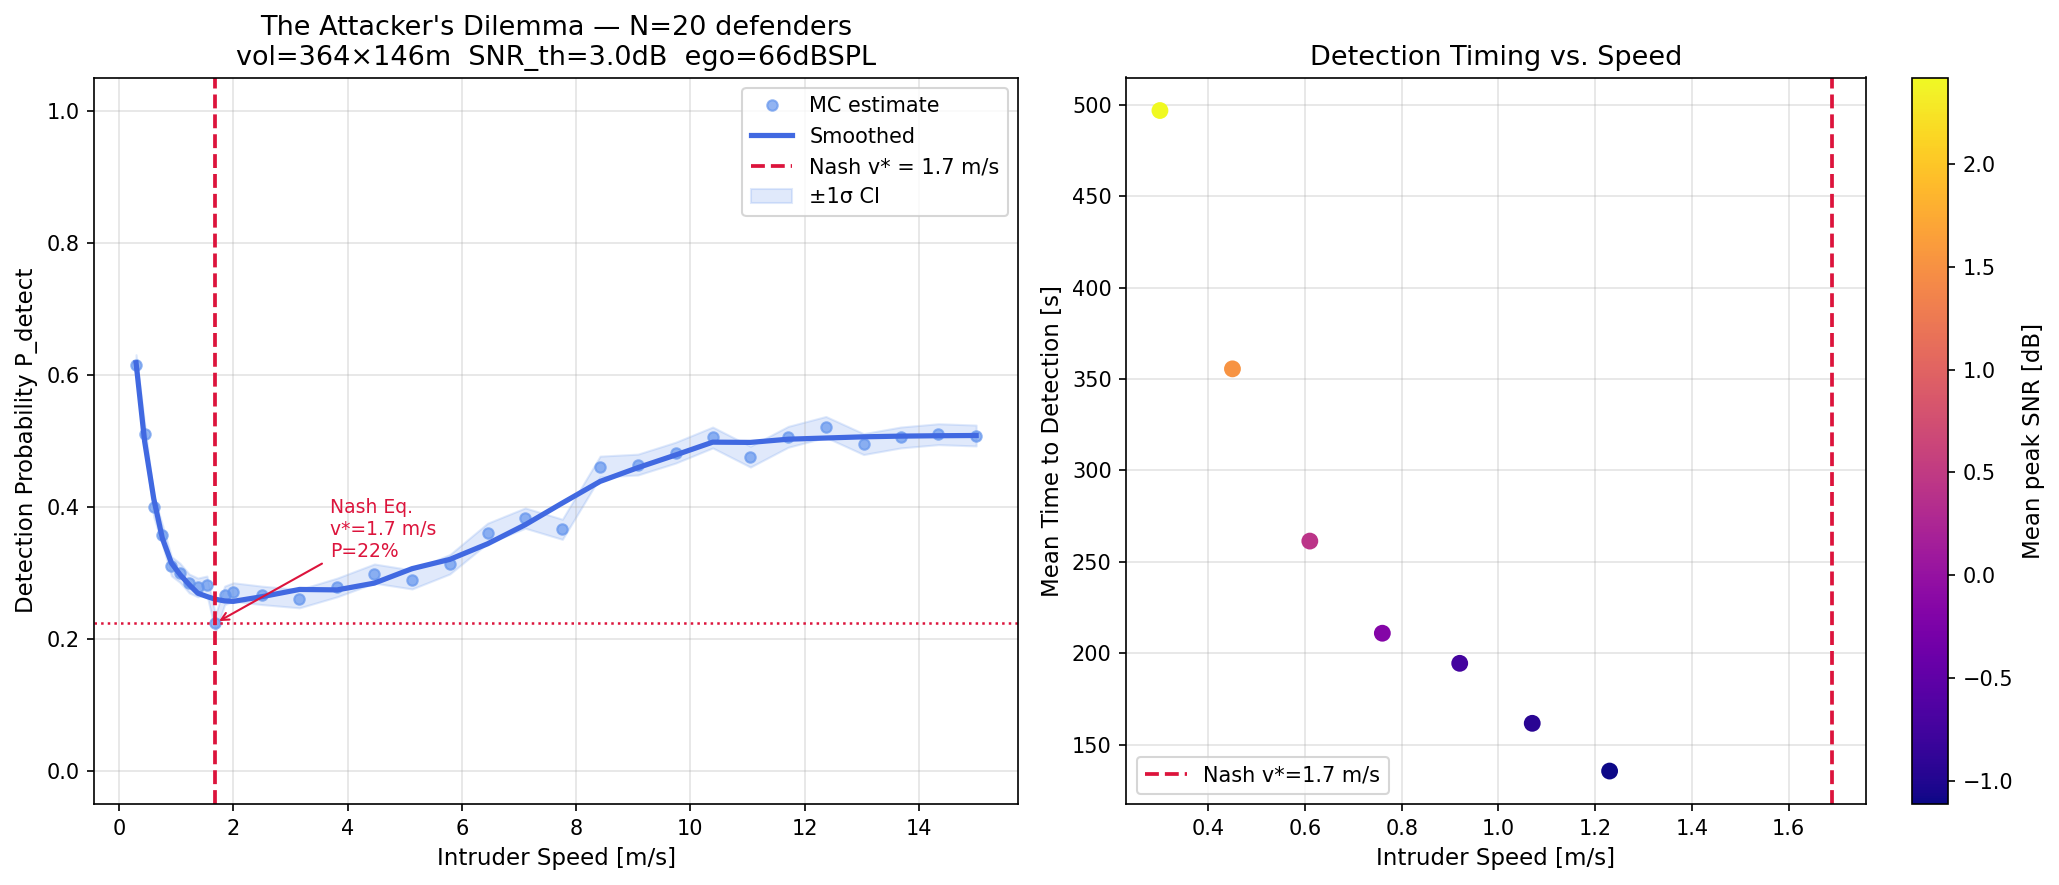

Results saved.


In [36]:
# ============================================================
# CELL 19 — EXPERIMENT 1: THE ATTACKER'S DILEMMA (U-CURVE)
# ============================================================
from scipy.signal import savgol_filter
import time as _time

print("=" * 60)
print("EXPERIMENT 1 — Attacker's Dilemma")
print(f"  N_defenders  = {SIM_CONFIG['N_defenders']}")
print(f"  n_runs/speed = {SIM_CONFIG['n_mc_exp1']}")
print(f"  speed range  = {SIM_CONFIG['intruder_speed_sweep'][[0,-1]]} m/s")
print(f"  batch size   = {SIM_CONFIG['mc_chunk_size']} runs/chunk (vectorised)")
print("=" * 60)

speed_sweep  = SIM_CONFIG["intruder_speed_sweep"]
results_exp1 = []
t0_exp1      = _time.perf_counter()

for v in tqdm(speed_sweep, desc="Exp1 speed sweep"):
    df_mc = run_monte_carlo(
        SIM_CONFIG,
        n_runs=SIM_CONFIG["n_mc_exp1"],
        override={"intruder_speed": float(v)},
        chunk_size=SIM_CONFIG["mc_chunk_size"],
        desc=f"v={v:.1f}")
    p_det    = df_mc["detected"].mean()
    mean_dt  = df_mc["detection_time"].dropna().mean()
    mean_snr = df_mc["max_snr"].mean()
    results_exp1.append({
        "speed": v, "p_detect": p_det,
        "mean_det_time": mean_dt, "mean_snr": mean_snr,
    })

t_tot = _time.perf_counter() - t0_exp1
print(f"\nExp1 done: {t_tot/60:.1f} min  "
      f"({t_tot/(len(speed_sweep)*SIM_CONFIG['n_mc_exp1'])*1000:.2f} ms/run)")

df_exp1 = pd.DataFrame(results_exp1)

# ── Nash equilibrium ──────────────────────────────────────────
min_idx = df_exp1["p_detect"].idxmin()
v_nash  = float(df_exp1.loc[min_idx, "speed"])
p_nash  = float(df_exp1.loc[min_idx, "p_detect"])
print(f"\n★  Nash equilibrium speed: v* = {v_nash:.2f} m/s  "
      f"(P_detect = {p_nash*100:.1f}%)")

# Smooth curve
wl = min(9, (len(df_exp1)//3)*2+1)
if wl % 2 == 0: wl -= 1
p_smooth = savgol_filter(df_exp1["p_detect"].to_numpy(), window_length=wl, polyorder=3)

# ── Plot ──────────────────────────────────────────────────────
spd_arr = df_exp1["speed"].to_numpy()
pdet_arr = df_exp1["p_detect"].to_numpy()
snr_arr  = df_exp1["mean_snr"].to_numpy()
mdt_arr  = df_exp1["mean_det_time"].to_numpy()

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax1 = axes[0]
ci = np.sqrt(pdet_arr * (1 - pdet_arr) / SIM_CONFIG["n_mc_exp1"])
ax1.plot(spd_arr, pdet_arr, "o", ms=5, alpha=0.7,
         color="cornflowerblue", label="MC estimate")
ax1.plot(spd_arr, p_smooth, "-", lw=2.5, color="royalblue", label="Smoothed")
ax1.axvline(v_nash, color="crimson", linestyle="--", lw=1.8,
            label=f"Nash v* = {v_nash:.1f} m/s")
ax1.axhline(p_nash, color="crimson", linestyle=":", lw=1.2)
ax1.fill_between(spd_arr, pdet_arr - ci, pdet_arr + ci,
                 alpha=0.2, color="cornflowerblue", label="±1σ CI")
if p_nash > 0.01:
    ax1.annotate(f"Nash Eq.\nv*={v_nash:.1f} m/s\nP={p_nash*100:.0f}%",
                 xy=(v_nash, p_nash),
                 xytext=(v_nash + 2.0, p_nash + 0.10),
                 arrowprops=dict(arrowstyle="->", color="crimson"),
                 fontsize=9, color="crimson")
ax1.set_xlabel("Intruder Speed [m/s]")
ax1.set_ylabel("Detection Probability P_detect")
ax1.set_title(f"The Attacker's Dilemma — N={SIM_CONFIG['N_defenders']} defenders\n"
              f"vol={SIM_CONFIG['vol_x']:.0f}×{SIM_CONFIG['vol_y']:.0f}m  "
              f"SNR_th={SIM_CONFIG['detection_snr_db']}dB  "
              f"ego={SIM_CONFIG['ego_noise_floor_db']:.0f}dBSPL")
ax1.set_ylim(-0.05, 1.05)
ax1.legend()

ax2 = axes[1]
sc = ax2.scatter(spd_arr, mdt_arr, c=snr_arr, cmap="plasma", s=50, zorder=5)
plt.colorbar(sc, ax=ax2, label="Mean peak SNR [dB]")
ax2.axvline(v_nash, color="crimson", ls="--", lw=1.8,
            label=f"Nash v*={v_nash:.1f} m/s")
ax2.set_xlabel("Intruder Speed [m/s]")
ax2.set_ylabel("Mean Time to Detection [s]")
ax2.set_title("Detection Timing vs. Speed")
ax2.legend()

plt.tight_layout()
plt.savefig(DATA_CONFIG["fig_dir"] + "fig3_exp1_dilemma.png", dpi=200)
plt.show()
df_exp1.to_csv(DATA_CONFIG["fig_dir"] + "exp1_results.csv", index=False)
print(f"Results saved.")

EXPERIMENT 2 — Swarm Scalability
  Intruder speed  = v* = 1.69 m/s  (Nash equilibrium)
  N sweep         = [3, 5, 8, 10, 15, 20, 30, 50, 75, 100, 125, 150, 175, 200]
  n_runs/N        = 500


Exp2 N sweep: 100%|██████████| 14/14 [00:13<00:00,  1.07it/s]


  → Auto-extending: adding N=[216, 232, 248, 264]  (predicted N_95%≈250)



Exp2 done: 20.3 s

★  N_min for 95% detection: 216 defenders
   Logistic fit: N₅₀=58.5, k=0.0331


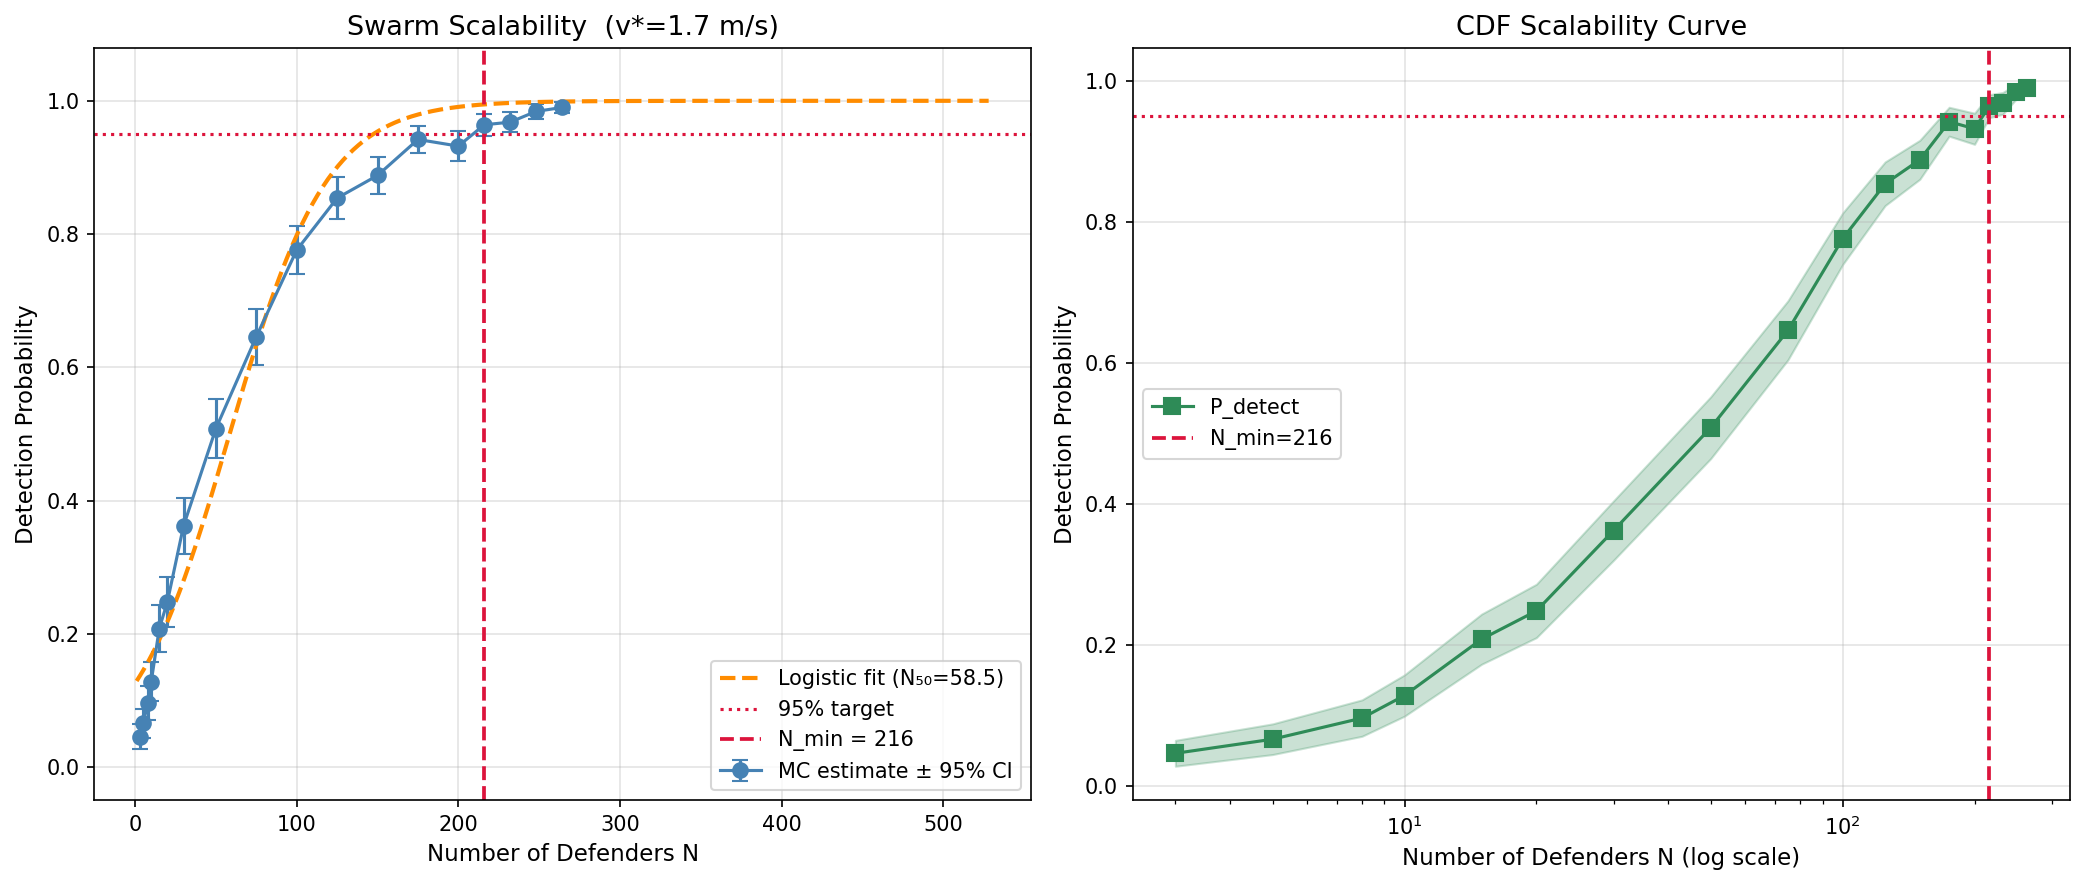

Results saved.


In [37]:
# ============================================================
# CELL 20 — EXPERIMENT 2: SWARM SCALABILITY
# ============================================================
import time as _time

print("=" * 60)
print("EXPERIMENT 2 — Swarm Scalability")
print(f"  Intruder speed  = v* = {v_nash:.2f} m/s  (Nash equilibrium)")
print(f"  N sweep         = {SIM_CONFIG['N_defenders_sweep']}")
print(f"  n_runs/N        = {SIM_CONFIG['n_mc_exp2']}")
print("=" * 60)

N_sweep      = list(SIM_CONFIG["N_defenders_sweep"])
results_exp2 = []
t0_exp2      = _time.perf_counter()

def _run_n_point(N):
    df_mc = run_monte_carlo(
        SIM_CONFIG,
        n_runs=SIM_CONFIG["n_mc_exp2"],
        override={"N_defenders": N, "intruder_speed": v_nash},
        chunk_size=SIM_CONFIG["mc_chunk_size"],
        desc=f"N={N}")
    p_det = df_mc["detected"].mean()
    ci_hw = 1.96 * np.sqrt(p_det * (1 - p_det) / SIM_CONFIG["n_mc_exp2"])
    return {
        "N_defenders": N,
        "p_detect":    p_det,
        "ci_lower":    max(0.0, p_det - ci_hw),
        "ci_upper":    min(1.0, p_det + ci_hw),
        "density_per_km3": N / (
            SIM_CONFIG["vol_x"] * SIM_CONFIG["vol_y"] *
            (SIM_CONFIG["defender_z_max"] - SIM_CONFIG["defender_z_min"]) / 1e9),
    }

# ── Initial sweep ────────────────────────────────────────────
for N in tqdm(N_sweep, desc="Exp2 N sweep"):
    results_exp2.append(_run_n_point(N))

# ── Auto-extend if 95% not reached ───────────────────────────
TARGET_PROB = 0.95
MAX_N_AUTO  = 500

for _attempt in range(8):
    df_exp2 = pd.DataFrame(results_exp2)
    if df_exp2["p_detect"].max() >= TARGET_PROB:
        break
    try:
        from scipy.optimize import curve_fit as _cf
        def _log(N, N50, k): return 1.0 / (1.0 + np.exp(-k * (N - N50)))
        _popt, _ = _cf(_log,
                        df_exp2["N_defenders"].to_numpy().astype(float),
                        df_exp2["p_detect"].to_numpy(),
                        p0=[100, 0.03], maxfev=5000)
        _N_pred = int(_popt[0] + np.log(19) / max(_popt[1], 0.001))
    except Exception:
        _N_pred = int(df_exp2["N_defenders"].max() * 1.5)

    _N_last = int(df_exp2["N_defenders"].max())
    if _N_pred <= _N_last:
        _N_pred = _N_last + 50

    # Add 3 evenly-spaced points up to predicted N_min
    _step = max(15, (_N_pred - _N_last) // 3)
    _new_Ns = [n for n in range(_N_last + _step, _N_pred + _step + 1, _step)
               if n not in N_sweep and n <= MAX_N_AUTO]
    if not _new_Ns:
        break
    print(f"  → Auto-extending: adding N={_new_Ns}  (predicted N_95%≈{_N_pred})")
    for _N in _new_Ns:
        N_sweep.append(_N)
        results_exp2.append(_run_n_point(_N))

t_tot = _time.perf_counter() - t0_exp2
print(f"\nExp2 done: {t_tot:.1f} s")
df_exp2 = pd.DataFrame(results_exp2)

# ── N_min for 95% detection ───────────────────────────────────
TARGET_PROB  = 0.95
above_target = df_exp2[df_exp2["p_detect"] >= TARGET_PROB]
if not above_target.empty:
    N_min = int(above_target.iloc[0]["N_defenders"])
    print(f"\n★  N_min for {TARGET_PROB*100:.0f}% detection: {N_min} defenders")
else:
    N_min = None
    print(f"\n[INFO] P_detect never reaches {TARGET_PROB*100:.0f}% in this sweep.")
    print(f"       Max P_detect = {df_exp2['p_detect'].max()*100:.1f}% at N={df_exp2.loc[df_exp2['p_detect'].idxmax(),'N_defenders']}")
    print(f"       Increase N_defenders_sweep or check detection range in calibration.")

# ── Logistic fit ─────────────────────────────────────────────
try:
    from scipy.optimize import curve_fit as _curve_fit
    def _logistic(N, N50, k): return 1.0 / (1.0 + np.exp(-k * (N - N50)))
    popt, _ = _curve_fit(_logistic,
                          df_exp2["N_defenders"].to_numpy().astype(float),
                          df_exp2["p_detect"].to_numpy(),
                          p0=[50, 0.05], maxfev=10000)
    N_fit = np.linspace(1, max(N_sweep) * 2, 500)
    P_fit = _logistic(N_fit, *popt)
    FIT_OK = True
    print(f"   Logistic fit: N₅₀={popt[0]:.1f}, k={popt[1]:.4f}")
except Exception as e:
    FIT_OK = False
    print(f"[WARN] Logistic fit failed: {e}")

# ── Plot ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

N_arr  = df_exp2["N_defenders"].to_numpy()
p_arr  = df_exp2["p_detect"].to_numpy()
cl_arr = df_exp2["ci_lower"].to_numpy()
cu_arr = df_exp2["ci_upper"].to_numpy()

ax1 = axes[0]
ax1.errorbar(N_arr, p_arr,
             yerr=[p_arr - cl_arr, cu_arr - p_arr],
             fmt="o-", ms=7, capsize=4, color="steelblue",
             label="MC estimate ± 95% CI")
if FIT_OK:
    ax1.plot(N_fit, P_fit, "--", lw=2, color="darkorange",
             label=f"Logistic fit (N₅₀={popt[0]:.1f})")
ax1.axhline(TARGET_PROB, color="crimson", ls=":", lw=1.5,
            label=f"{TARGET_PROB*100:.0f}% target")
if N_min:
    ax1.axvline(N_min, color="crimson", ls="--", lw=1.8,
                label=f"N_min = {N_min}")
ax1.set_xlabel("Number of Defenders N")
ax1.set_ylabel("Detection Probability")
ax1.set_title(f"Swarm Scalability  (v*={v_nash:.1f} m/s)")
ax1.set_ylim(-0.05, 1.08)
ax1.legend()

ax2 = axes[1]
ax2.semilogx(N_arr, p_arr, "s-", ms=8, color="seagreen", label="P_detect")
ax2.fill_between(N_arr, cl_arr, cu_arr, alpha=0.25, color="seagreen")
ax2.axhline(TARGET_PROB, color="crimson", ls=":", lw=1.5)
if N_min:
    ax2.axvline(N_min, color="crimson", ls="--", lw=1.8, label=f"N_min={N_min}")
ax2.set_xlabel("Number of Defenders N (log scale)")
ax2.set_ylabel("Detection Probability")
ax2.set_title("CDF Scalability Curve")
ax2.legend()

plt.tight_layout()
plt.savefig(DATA_CONFIG["fig_dir"] + "fig4_exp2_scalability.png", dpi=200)
plt.show()
df_exp2.to_csv(DATA_CONFIG["fig_dir"] + "exp2_results.csv", index=False)
print("Results saved.")

EXPERIMENT 3 — Altitude × Speed Detection Heatmap
  n_runs/cell = 300


Exp3 altitude sweep: 100%|██████████| 6/6 [00:09<00:00,  1.66s/it]



Exp3 done: 0.2 min


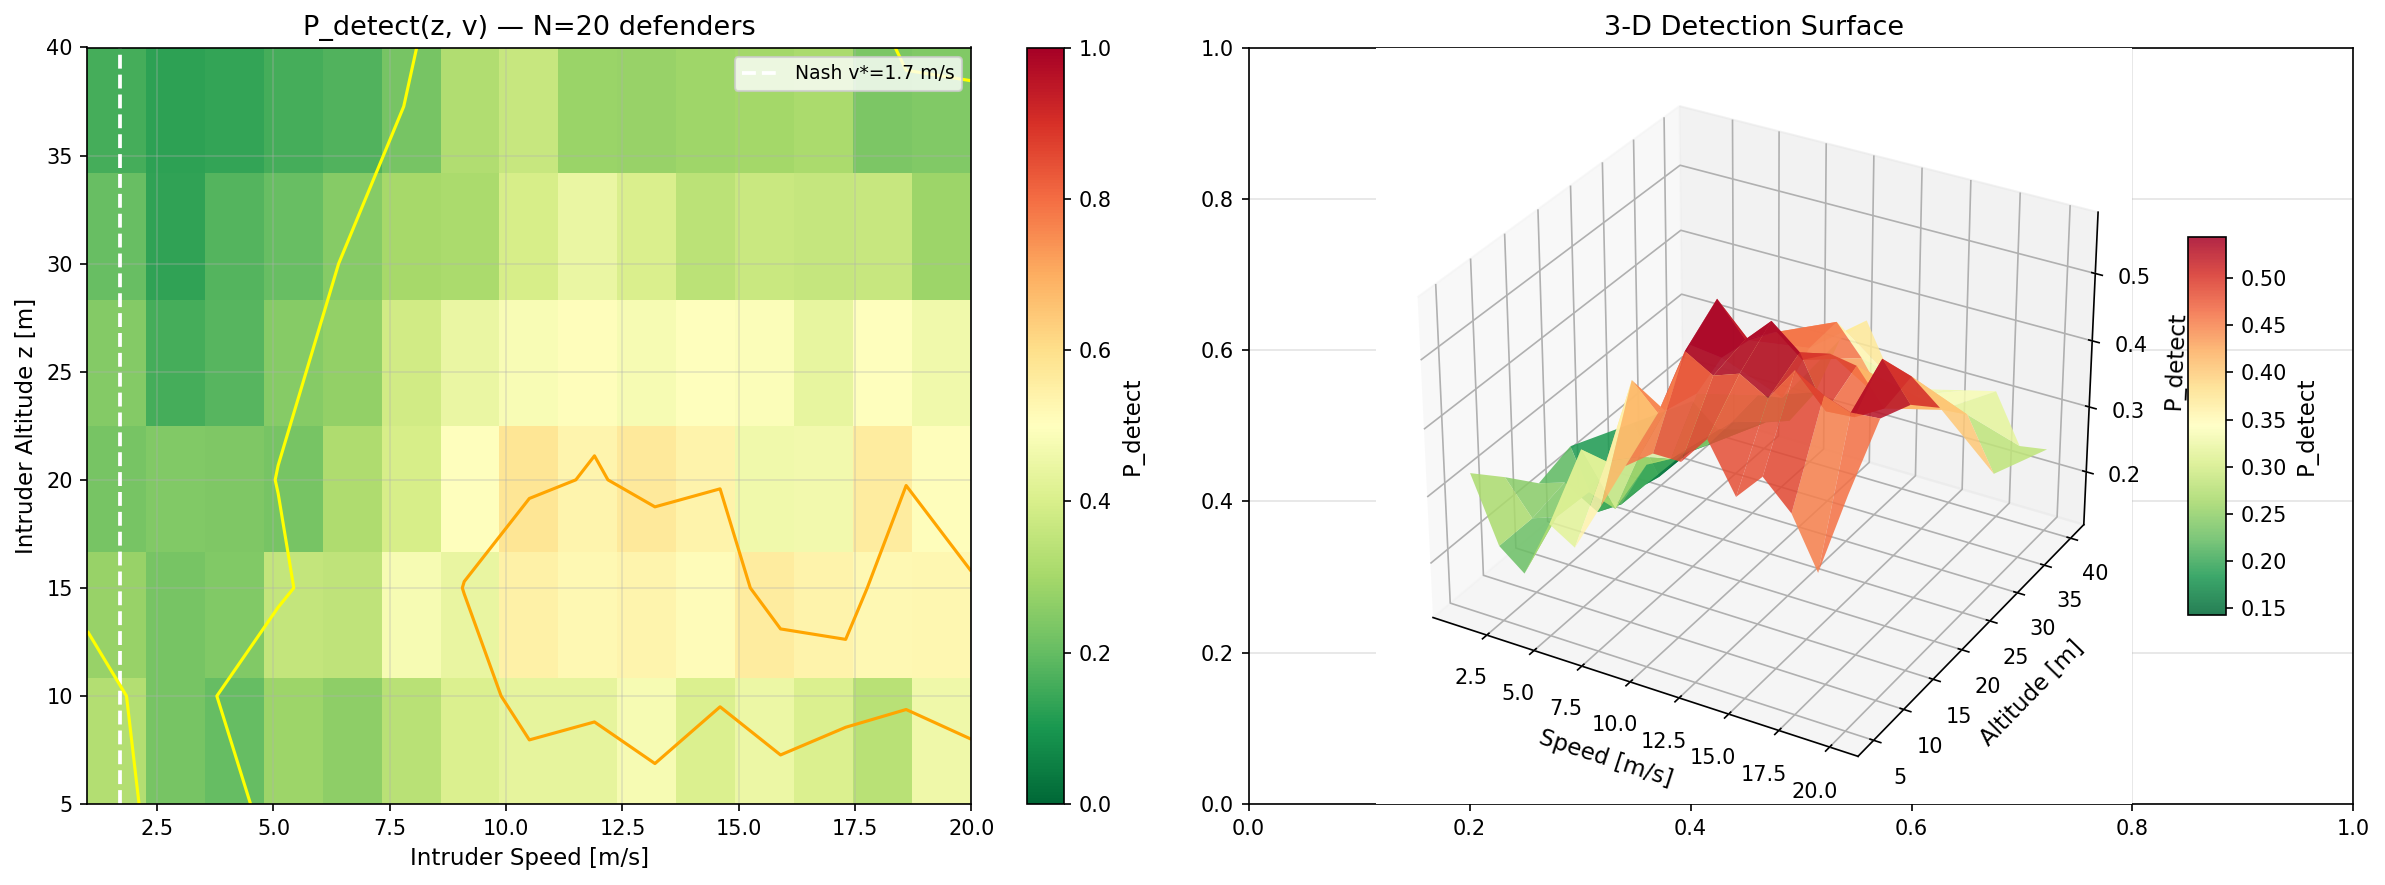

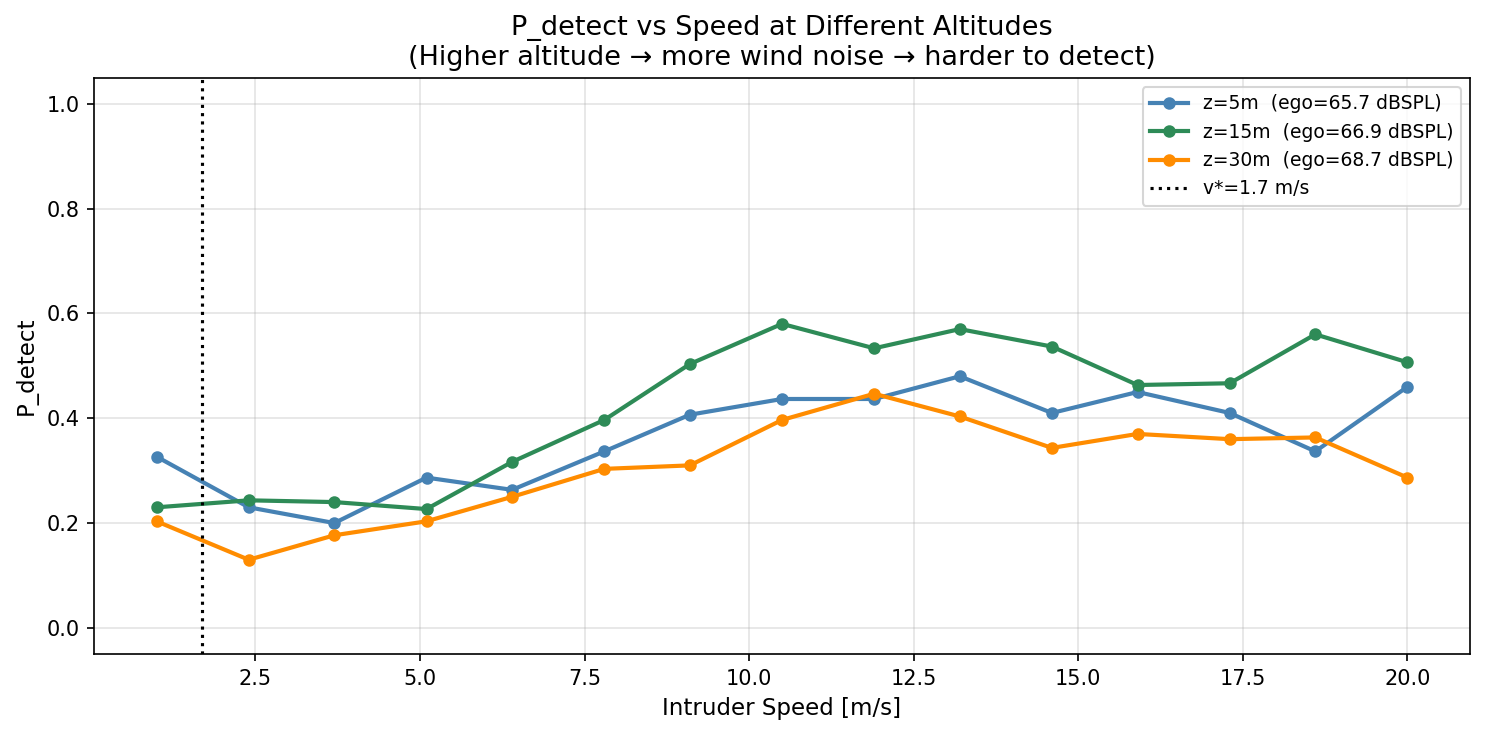

Experiment 3 complete.


In [38]:
# ============================================================
# CELL 21 — EXPERIMENT 3: 3-D HEATMAP & ALTITUDE EFFECT
# ============================================================
import time as _time

print("=" * 60)
print("EXPERIMENT 3 — Altitude × Speed Detection Heatmap")
print(f"  n_runs/cell = {SIM_CONFIG['n_mc_exp3']}")
print("=" * 60)

z_values = np.array([5, 10, 15, 20, 30, 40, 55, 70, 90], dtype=float)
# Clip z to defender altitude range
z_values = z_values[z_values <= SIM_CONFIG["defender_z_max"]]
v_values = np.round(np.linspace(1.0, 20.0, 15), 1)

P_map = np.zeros((len(z_values), len(v_values)))
t0_exp3 = _time.perf_counter()

for i, z_int in enumerate(tqdm(z_values, desc="Exp3 altitude sweep")):
    for j, v_int in enumerate(v_values):
        df_mc = run_monte_carlo(
            SIM_CONFIG,
            n_runs=SIM_CONFIG["n_mc_exp3"],
            override={"intruder_speed": float(v_int),
                      "intruder_z":     float(z_int)},
            chunk_size=SIM_CONFIG["mc_chunk_size"],
            desc="")
        P_map[i, j] = df_mc["detected"].mean()

t_tot = _time.perf_counter() - t0_exp3
print(f"\nExp3 done: {t_tot/60:.1f} min")

# ── 2-D Heatmap ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ax1 = axes[0]
im = ax1.imshow(P_map, aspect="auto", origin="lower",
                extent=[v_values.min(), v_values.max(),
                        z_values.min(), z_values.max()],
                cmap="RdYlGn_r", vmin=0, vmax=1)
plt.colorbar(im, ax=ax1, label="P_detect")
ax1.axvline(v_nash, color="white", ls="--", lw=1.8,
            label=f"Nash v*={v_nash:.1f} m/s")
# Contour lines only if there's variation
if P_map.max() > 0.1:
    levels = [l for l in [0.25, 0.5, 0.75] if P_map.min() < l < P_map.max()]
    if levels:
        ax1.contour(v_values, z_values, P_map, levels=levels,
                    colors=["yellow", "orange", "red"][:len(levels)],
                    linewidths=1.5)
ax1.set_xlabel("Intruder Speed [m/s]")
ax1.set_ylabel("Intruder Altitude z [m]")
ax1.set_title(f"P_detect(z, v) — N={SIM_CONFIG['N_defenders']} defenders")
ax1.legend(fontsize=9)

ax2 = fig.add_subplot(122, projection="3d")
V_grid, Z_grid = np.meshgrid(v_values, z_values)
surf = ax2.plot_surface(V_grid, Z_grid, P_map,
                         cmap="RdYlGn_r", alpha=0.85,
                         linewidth=0, antialiased=True)
fig.colorbar(surf, ax=ax2, shrink=0.5, aspect=10, label="P_detect")
ax2.set_xlabel("Speed [m/s]"); ax2.set_ylabel("Altitude [m]"); ax2.set_zlabel("P_detect")
ax2.set_title("3-D Detection Surface"); ax2.view_init(elev=30, azim=-60)

plt.tight_layout()
plt.savefig(DATA_CONFIG["fig_dir"] + "fig5_exp3_heatmap.png", dpi=200)
plt.show()

# ── Altitude slices ───────────────────────────────────────────
fig2, ax3 = plt.subplots(figsize=(10, 5))
slice_alts = [z for z in [5, 15, 30, 55] if z <= z_values.max()]
colors_h = ["steelblue", "seagreen", "darkorange", "crimson"]
for z_h, c in zip(slice_alts, colors_h):
    idx_z = np.argmin(np.abs(z_values - z_h))
    ego   = float(ego_noise_at_altitude(z_h))
    ax3.plot(v_values, P_map[idx_z, :], "o-", lw=2, ms=5, color=c,
             label=f"z={z_h:.0f}m  (ego={ego:.1f} dBSPL)")
ax3.axvline(v_nash, color="black", ls=":", lw=1.5, label=f"v*={v_nash:.1f} m/s")
ax3.set_xlabel("Intruder Speed [m/s]"); ax3.set_ylabel("P_detect")
ax3.set_title("P_detect vs Speed at Different Altitudes\n"
              "(Higher altitude → more wind noise → harder to detect)")
ax3.set_ylim(-0.05, 1.05)
ax3.legend(fontsize=9)
plt.tight_layout()
plt.savefig(DATA_CONFIG["fig_dir"] + "fig5b_exp3_altitude_slices.png", dpi=200)
plt.show()

np.save(DATA_CONFIG["fig_dir"] + "exp3_P_map.npy", P_map)
pd.DataFrame(P_map, index=z_values, columns=v_values).to_csv(
    DATA_CONFIG["fig_dir"] + "exp3_heatmap.csv")
print("Experiment 3 complete.")